# Лабораторная работа №3
## «Классификация временных рядов и их прогнозирование на примере метеоданных шести городов России»
Клиент — региональный центр гидрометеорологии, осуществляющий мониторинг погодных условий на территории РФ с целью оперативного прогнозирования опасных явлений и предоставления точных среднесрочных прогнозов (на месяц вперед) для городских служб, авиации, сельского хозяйства и МЧС.

В настоящее время центр располагает историческими данными с метеостанций шести городов: Москва, Сочи, Благовещенск, Находка, Геленджик, Санкт-Петербург. Данные собираются ежечасно (или ежедневно) за период 2019–2025 годов и содержат информацию о температуре, влажности, осадках, скорости ветра, атмосферном давлении и других параметрах.
Специалисты центра сталкиваются со следующими проблемами:
Прогнозирование погоды на месяц вперед является сложной задачей из-за хаотичности атмосферных процессов
Различные типы климата требуют различных подходов к прогнозированию: то, что работает для Москвы, может не работать для Сочи

Отсутствует автоматизированная система, которая сначала определяет тип климата (город) по текущему временному ряду, а затем применяет специализированную прогнозную модель

Существующие универсальные модели прогнозирования показывают неудовлетворительную точность для всех городов одновременно

**Исходные данные доступны по** [ссылке](https://drive.google.com/drive/folders/1TiElgCkYv07p_9zbKEfmwHpD7pSPlmyT?usp=sharing):

Для каждого города переданы файлы вида {Город}_2019-01-01_2019-12-31.parquet за 2019-2025 года. Источник - open-meteo.

Каждый файл содержит колонки: temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure.

Ожидаемый результат: Ссылка на Git-репозиторий с:
- Jupyter Notebook с полным пайплайном решения
- requirements.txt с зависимостями
- README.md с инструкцией по запуску и интерпретации результатов

## 2. Задание
Реализовать двухэтапную систему анализа временных рядов:

1.	Этап 1 — Классификация: по временному ряду метеопараметров за фиксированный период определить, к типу климата относится ряд. Для каждого типа климата представлено как минимум 2 города.
2.	Этап 2 — Прогнозирование: для каждого города построить отдельную модель прогнозирования температуры (и, опционально, осадков) на месяц вперед, после чего объединить этапы в единый пайплайн.

### 2.1. Разведочный анализ данных (EDA)
Для каждого из шести городов:
- Провести визуальный анализ всех показателей телеметрии: тренды, сезонность (суточная, годовая), выбросы, пропуски
- Исследовать распределение каждого признака (гистограммы, box-plot, Q-Q plot для проверки нормальности)
- Выявить и визуализировать сезонные паттерны (по месяцам, по временам года)
- Проанализировать корреляции между всеми признаками (тепловая карта корреляционной матрицы)

Кросс-городской анализ:
- Сравнить распределения температуры и осадков между городами
- Визуализировать климатические профили городов (среднемесячные температуры, среднегодовые осадки)
- Выявить аномалии и выбросы в межгородском сравнении
- Провести анализ пропусков: определить характер пропусков, предложить стратегию их обработки

Анализ стационарности:
- Проверить ряды на стационарность (тест Дики-Фуллера) для каждого города
- Применить дифференцирование для приведения к стационарному виду при необходимости
- Обосновать выбор методов обработки нестационарности в контексте прогнозирования

Обосновать:
- Выбор метода интерполяции пропусков в контексте метеоданных
- Стратегию обработки выбросов (с учетом возможности экстремальных погодных явлений)
- Необходимость ресемплинга данных к единой временной частоте

### 2.2. Инжиниринг признаков для временных рядов
Временные признаки:
- Извлечь из временного индекса: час, день недели, день месяца, месяц, сезон, год
- Создать циклические признаки (sin/cos) для часа и месяца для учета циклического характера времени

Лаговые признаки

Скользящие статистики

Признаки динамики:
- Вычислить производные (скорость изменения температуры: разница между текущим и предыдущим значением)
- Вычислить ускорение (разница скоростей)
- Добавить признаки темпа роста давления

Агрегированные признаки для классификации:
- Для каждого окна вычислить статистики, характеризующие тип погодного режима (амплитуда температур, количество дней с осадками, максимальный порыв ветра, средняя температура, стандартное отклонение)
- Создать признак «климатическая норма» для данного дня года (среднее за все годы)

Снижение размерности:
- Применить PCA для визуализации разделимости городов в пространстве признаков
- При необходимости выполнить отбор признаков на основе важности (feature importance)

Обосновать:
- Выбор размеров окон для скользящих статистик с точки зрения физики атмосферных процессов
- Выбор лагов с учетом временной корреляции метеовеличин

### 2.3. Построение моделей классификации
Обосновать архитектуру модели для классификации временных рядов.

Привести письменное обоснование:
- Какие модели заведомо не подойдут для этой задачи и почему
- Какие особенности данных делают задачу классификации сложной

Обучить выбранную модель. Указать выбранную длину временного ряда для тестирования классификатора.

### 2.4. Оценка качества классификации
Основные метрики:
- Accuracy, Precision, Recall, F1-score (macro и weighted)
- Матрица ошибок (confusion matrix) для визуализации типичных ошибок классификации
- ROC-AUC для многоклассовой задачи (One-vs-Rest)

Дополнительный анализ:
- Определить, какие города/климаты наиболее трудноразличимы (анализ матрицы ошибок)
- Проанализировать, какие временные периоды (зима/лето/межсезонье) дают лучшую/худшую классификацию
- Провести анализ важности признаков для лучшей модели (SHAP, permutation importance)
- Визуализировать ошибки классификации во временной динамике (по месяцам, по годам)

### 2.5. Построение моделей прогнозирования
Для каждого города отдельно:
- Сформировать выборку для прогнозирования: признаки — значения метеопараметров за последние N дней, целевая переменная — температура через горизонт H = 30 дней
- Разделить данные на train/val/test (например, 2019–2023 — train, 2024 — val, 2025 — test)

Обосновать архитектуру модели прогнозирования для каждой климатической зоны. Допускается использовать разные.

Привести письменное обоснование:
- Почему для разных климатических зон могут быть оптимальны разные модели
- Какие модели точно не подойдут для прогнозирования на месяц и почему

Обучить модели, чтобы для каждого города предсказывать погоду для каждого дня в течение следующего месяца.

### 2.6. Оценка качества прогнозирования
Точечные метрики:
- MAE, RMSE, MAPE, WAPE (для каждого города и горизонта)

Метрики, оценивающие направление предсказаний

Анализ остатков:
- Нормальность остатков (тест Шапиро-Уилка)
- Автокорреляция остатков (тест Льюнга-Бокса)
- Гетероскедастичность (тест Уайта)

Визуализация:
- Сравнить прогнозы с реальными значениями на тестовом периоде (графики)
- Визуализировать распределение ошибок для разных городов (box-plot)
- Показать прогноз на месяц вперед для каждого города

### 2.7. Интеграция двух этапов в единый пайплайн
### 2.8. Документирование и интерпретация
- Каждый этап решения снабдить поясняющими комментариями в коде
- По завершении каждого из пунктов 2.1–2.7 сформулировать аналитические выводы
- Создать итоговую сводную таблицу с результатами всех экспериментов
- Подготовить выводы о применимости двухэтапного подхода для прогнозирования метеоданных


# Решение.

In [1]:
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1TiElgCkYv07p_9zbKEfmwHpD7pSPlmyT

Retrieving folder contents
Processing file 1ArON_bAPuObqKBQ4B-ClU2WbvdQLM9nN Благовещенск_2019-01-01_2019-12-31.parquet
Processing file 1Fv451zyTVHJXiUOONuZagitWqIo8-F_m Благовещенск_2020-01-01_2020-12-31.parquet
Processing file 1rOc108SjDZlNq8r1Tm_s9zUwt11SO9_l Благовещенск_2021-01-01_2021-12-31.parquet
Processing file 1dimbV-kQv1mzWe3E__BtSEKc4j75aYiq Благовещенск_2022-01-01_2022-12-31.parquet
Processing file 18AIzRtG5mzibcjCtDbyjb6x6hRGZYoh4 Благовещенск_2023-01-01_2023-12-31.parquet
Processing file 1No2nVrdHgSijDU6Esxv4R2GLa6mWxjqc Благовещенск_2024-01-01_2024-12-31.parquet
Processing file 1WXvIK-7WvBrwYEtBp2w_bwuwBMPjz8oU Благовещенск_2025-01-01_2025-12-31.parquet
Processing file 1mB-A9Hdo66xg57j4g6i07spZKJ_nBfkJ Геленджик_2019-01-01_2019-12-31.parquet
Processing file 1Gn0jGDF9JkMAGr7kCUrkaTpWo1dtnSaA Геленджик_2020-01-01_2020-12-31.parquet
Processing file 1wP-GIXG6jpzd-iqroJVL-hbEI5ZeIeIo Геленджик_2021-01-01_2021-12-31.parquet
Processing file 18Qd2c2kILBOVOnr6r9J5UnCUAw73OvWl Ге

In [2]:
import pandas as pd
from pandas import DataFrame
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

In [3]:
os.listdir("/content")

['.config', 'данные', 'sample_data']

In [4]:
df = pd.read_parquet("/content/данные/Москва_2019-01-01_2019-12-31.parquet")

In [5]:
# изучение колонок в файле parquet
df.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
time,,,,,,,,
2019-01-01 00:00:00,-6.5,92,0.0,0.0,0.0,3,10.8,1000.500000
2019-01-01 01:00:00,-6.8,92,0.0,0.0,0.0,3,10.5,1000.299988
2019-01-01 02:00:00,-6.8,92,0.0,0.0,0.0,3,10.8,1000.000000
2019-01-01 03:00:00,-5.8,93,0.0,0.0,0.0,3,12.2,999.299988
2019-01-01 04:00:00,-5.9,93,0.0,0.0,0.0,3,14.4,998.599976


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        8760 non-null   float32
 1   relative_humidity_2m  8760 non-null   int64  
 2   precipitation         8760 non-null   float32
 3   rain                  8760 non-null   float32
 4   snowfall              8760 non-null   float32
 5   weathercode           8760 non-null   int64  
 6   wind_speed_10m        8760 non-null   float32
 7   surface_pressure      8760 non-null   float32
dtypes: float32(6), int64(2)
memory usage: 410.6 KB


Решение пройтись по всем parquet файлам и положить все в единый dataset с дополнительной колонкой city с наименованием города из имени файла

In [7]:
parquets: list = glob.glob("/content/данные/*.parquet", recursive=True)

dfs: list[DataFrame] = []

for file_parquet in parquets:
    filename = os.path.basename(file_parquet)
    #print(f"Изучение {filename}")
    df_parquet = pd.read_parquet(file_parquet)
    df_parquet = df_parquet.reset_index()
    df_parquet["city"] = filename.split("_")[0]  # Москва_2019-01-01_2019-12-31.parquet
    #df_parquet["time"] = pd.to_datetime(df_parquet["time"])

    dfs.append(df_parquet)

df: DataFrame = pd.concat(dfs, ignore_index=True)

columns: list[str] = list(df.columns)
columns.remove("city")
column_time_index: int = columns.index("time") + 1
columns.insert(column_time_index, "city")
df = df[columns]
df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(["city", "time"])
#df = df.set_index("time")
#df = df.sort_index()

In [8]:
print(df.shape)
df.head()

(368208, 10)


,time,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
271800,2019-01-01 00:00:00,Благовещенск,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012
271801,2019-01-01 01:00:00,Благовещенск,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000
271802,2019-01-01 02:00:00,Благовещенск,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988
271803,2019-01-01 03:00:00,Благовещенск,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024
271804,2019-01-01 04:00:00,Благовещенск,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000


In [9]:
# проверка, что все в порядке, и время в колонке time осталось
#df.index[100]

In [10]:
cities: list[str] = df["city"].unique()
cities

array(['Благовещенск', 'Геленджик', 'Москва', 'Находка',
       'Санкт-Петербург', 'Сочи'], dtype=object)

### 2.1. Разведочный анализ данных (EDA) Для каждого из шести городов:
#### - Провести визуальный анализ всех показателей телеметрии: тренды, сезонность (суточная, годовая), выбросы, пропуски

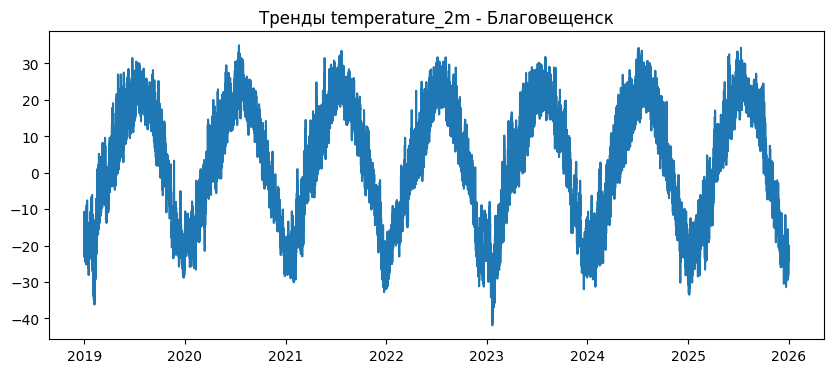

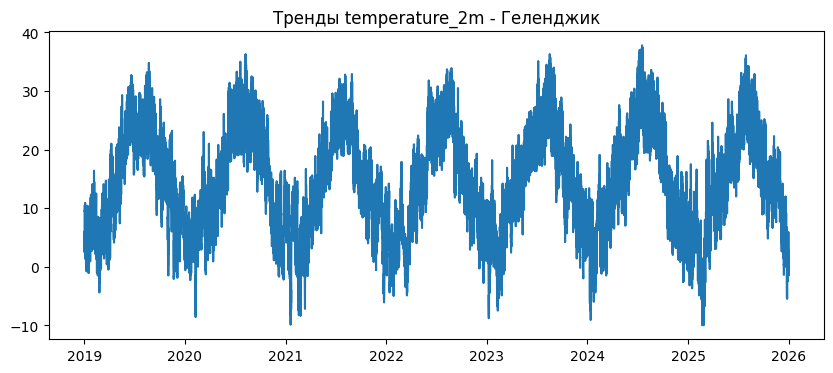

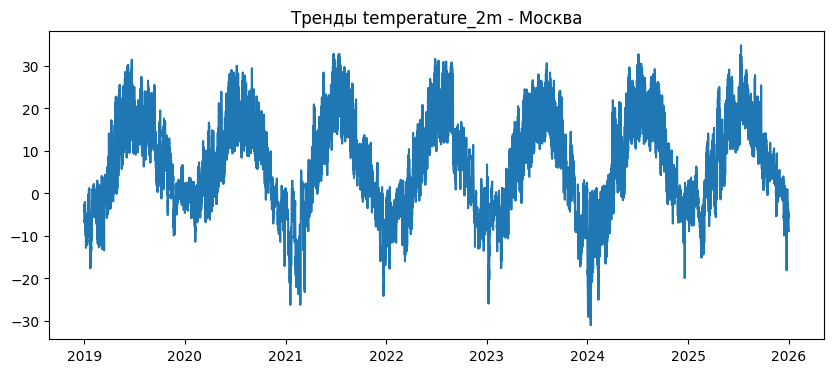

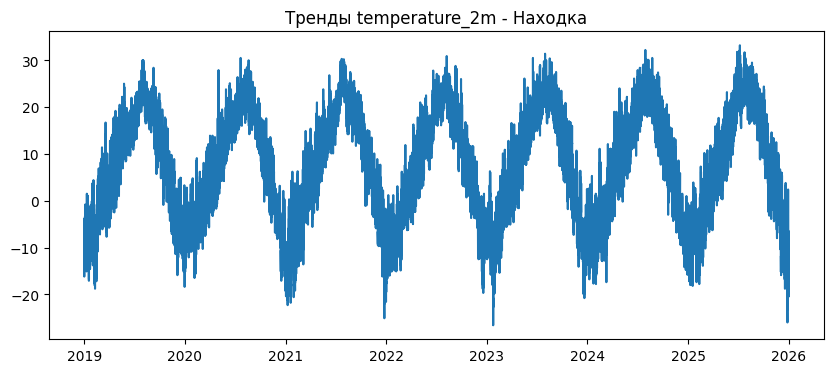

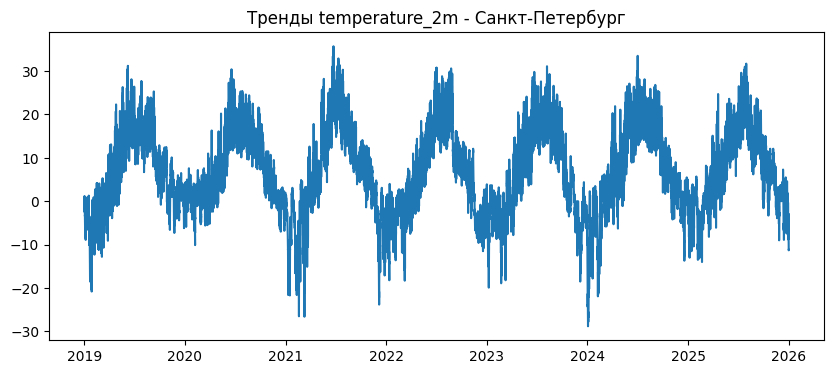

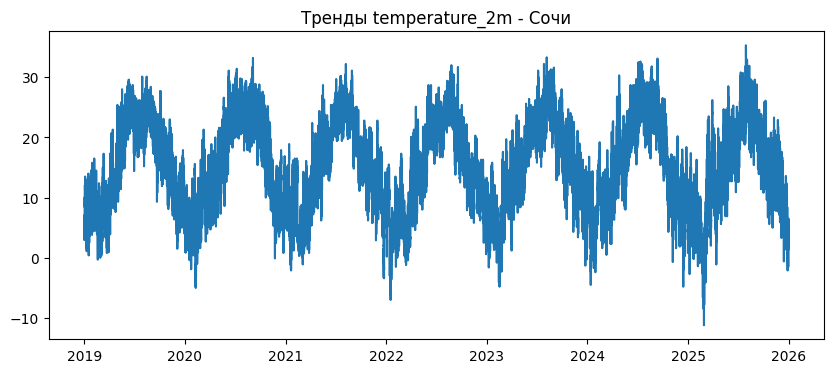

In [11]:
for city in cities:
  tmp = df[df["city"] == city]

  plt.figure(figsize=(10,4))
  plt.plot(tmp["time"], tmp["temperature_2m"])
  plt.title(f"Тренды temperature_2m - {city}")
  plt.show()

Для всех городов наблюдается выраженная годовая сезонность температуры с максимумом температуры в летние месяцы и минимумом в зимние. Долгосрочного тренда (устойчивого роста или снижения температуры за 2019–2025 годы) не выявлено.

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


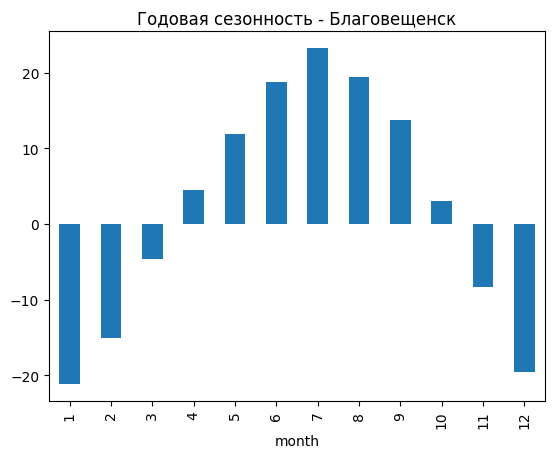

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


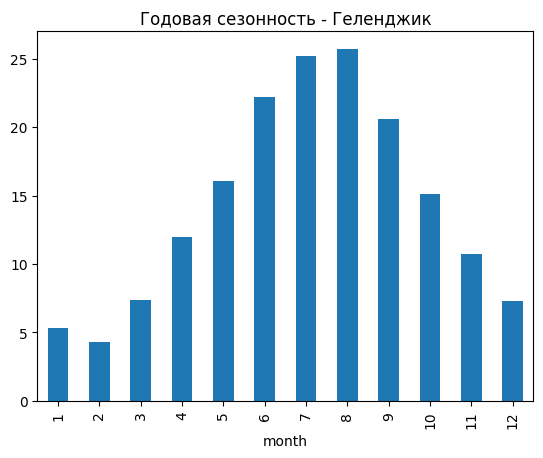

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


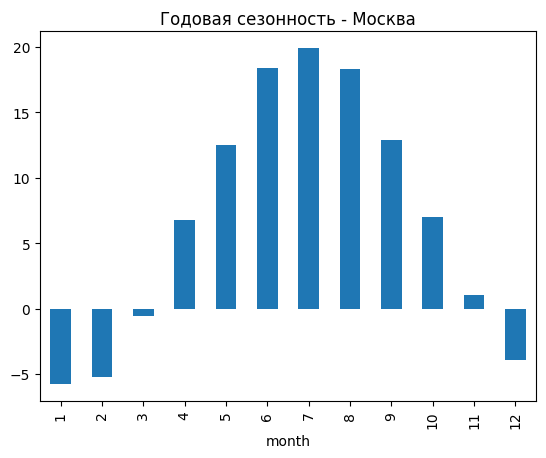

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


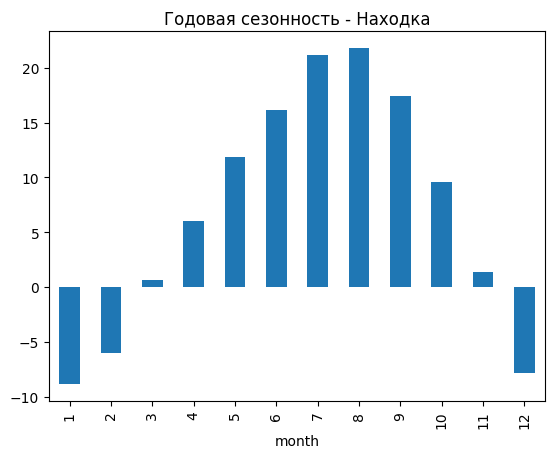

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


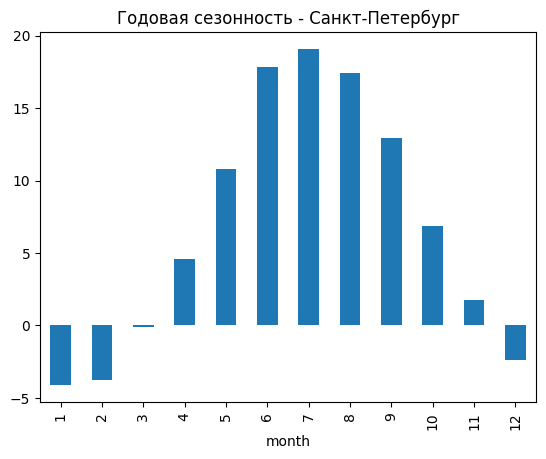

/tmp/ipykernel_4507/9219765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["month"] = tmp["time"].dt.month


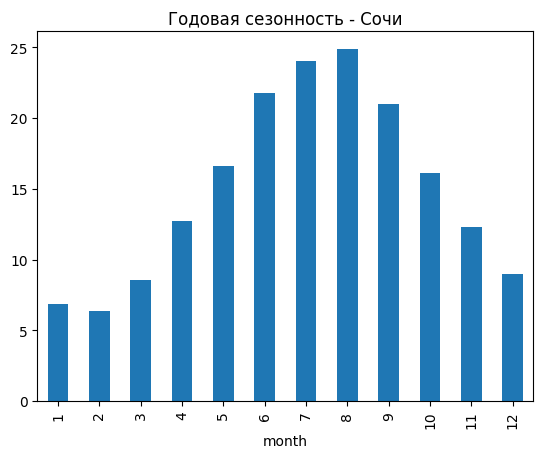

In [12]:
for city in cities:
  tmp = df[df["city"] == city]

  tmp["month"] = tmp["time"].dt.month
  monthly = tmp.groupby("month")["temperature_2m"].mean()
  plt.figure()
  monthly.plot(kind="bar")
  plt.title(f"Годовая сезонность - {city}")
  plt.show()

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


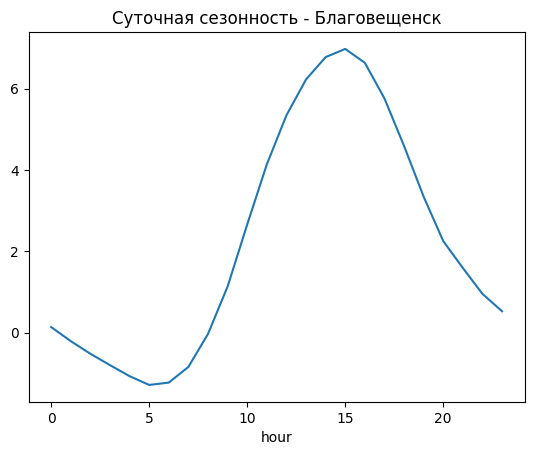

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


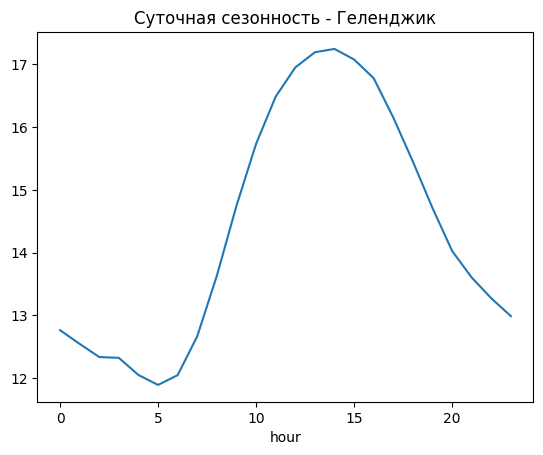

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


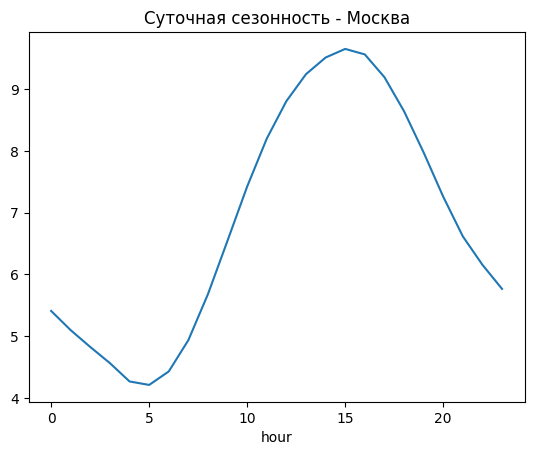

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


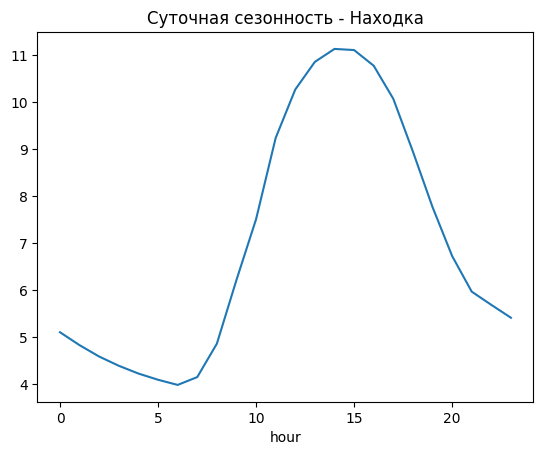

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


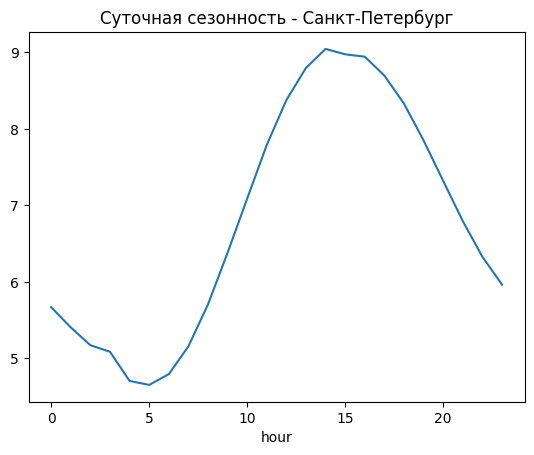

/tmp/ipykernel_4507/2376748130.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["hour"] = tmp["time"].dt.hour


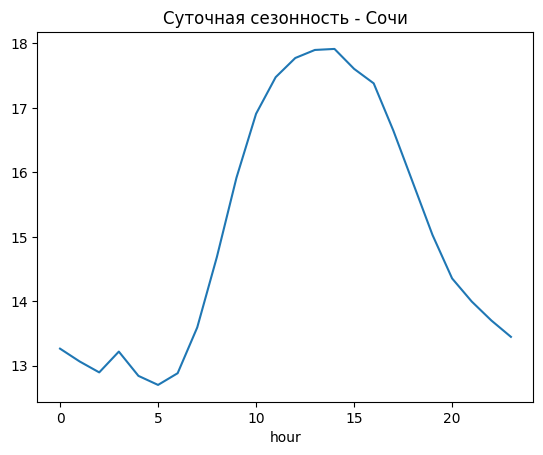

In [13]:
for city in cities:
  tmp = df[df["city"] == city]

  tmp["hour"] = tmp["time"].dt.hour
  hourly = tmp.groupby("hour")["temperature_2m"].mean()
  plt.figure()
  hourly.plot()
  plt.title(f"Суточная сезонность - {city}")
  plt.show()

Во всех городах наблюдается выраженная суточная сезонность: минимальные температуры фиксируются в ночные часы, максимальные — в дневные. Амплитуда суточных колебаний различается между городами.

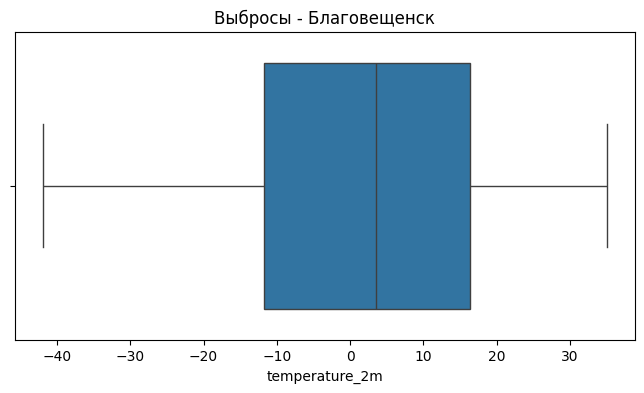

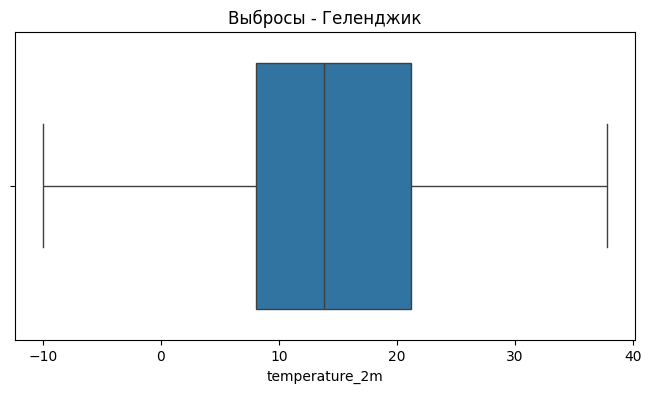

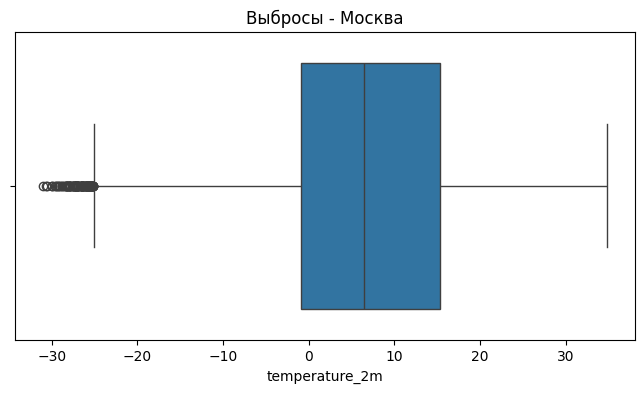

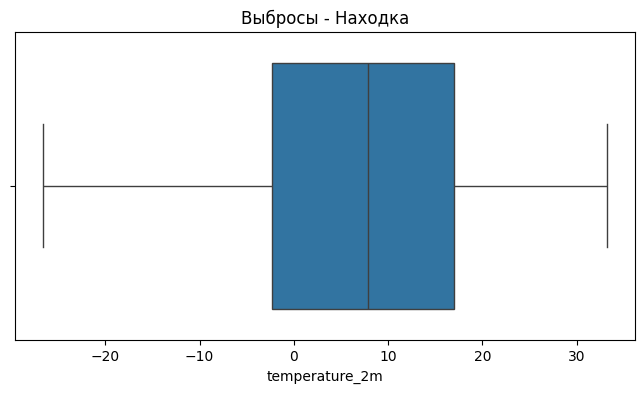

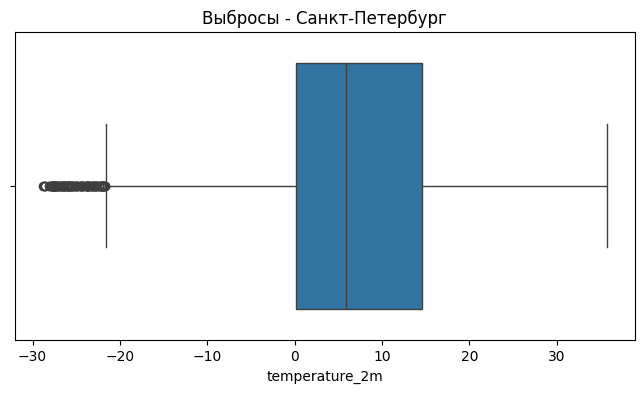

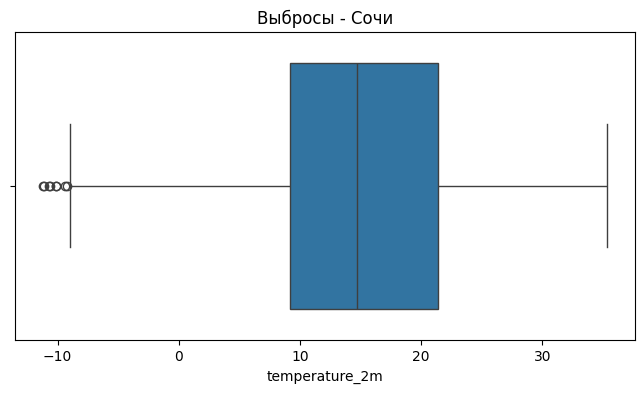

In [14]:
# анализ выбросов
for city in cities:
  tmp = df[df["city"] == city]

  plt.figure(figsize=(8,4))
  sns.boxplot(x=tmp["temperature_2m"])
  plt.title(f"Выбросы - {city}")
  plt.show()

Обнаружены выбросы в распределении температуры, соответствующие экстремально низким значениям в зимний период. Эти значения являются обоснованными и предлагается не удалять.

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


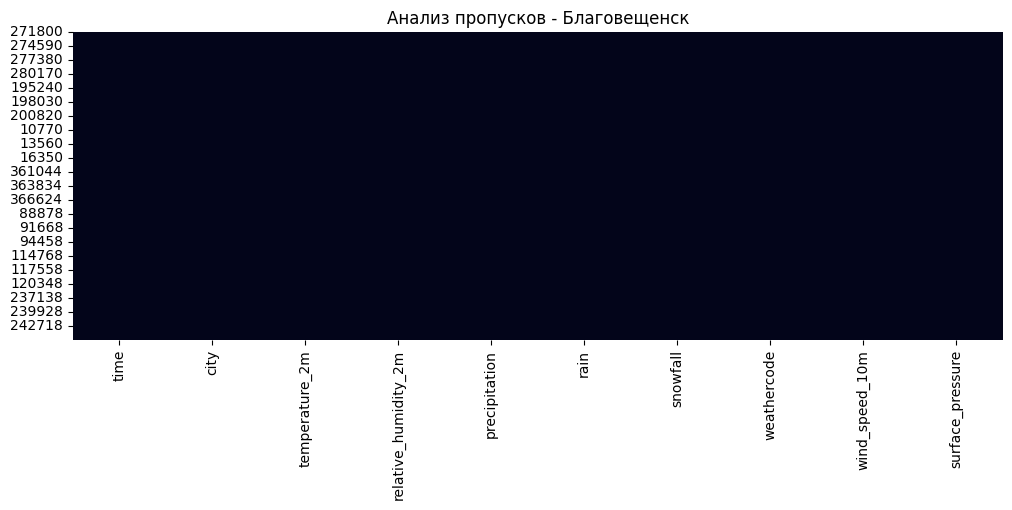

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


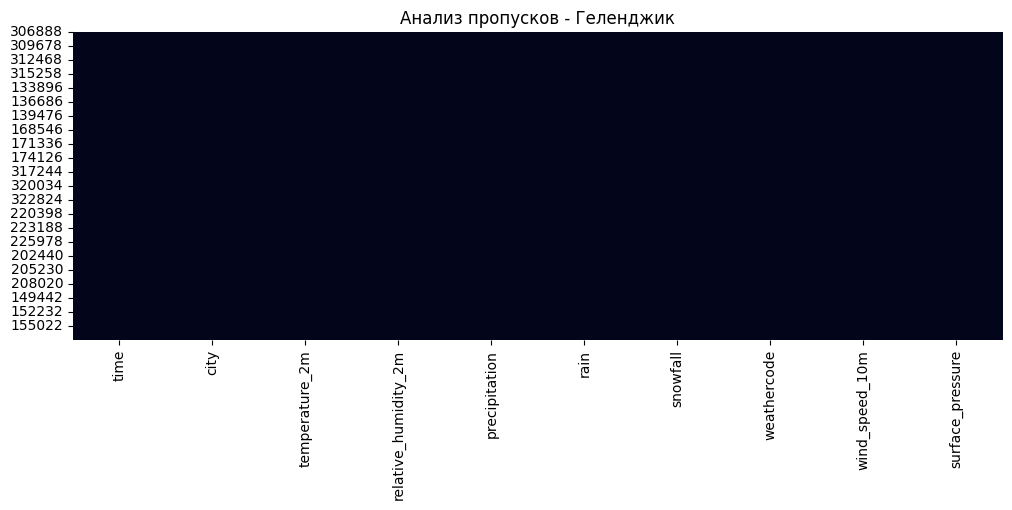

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


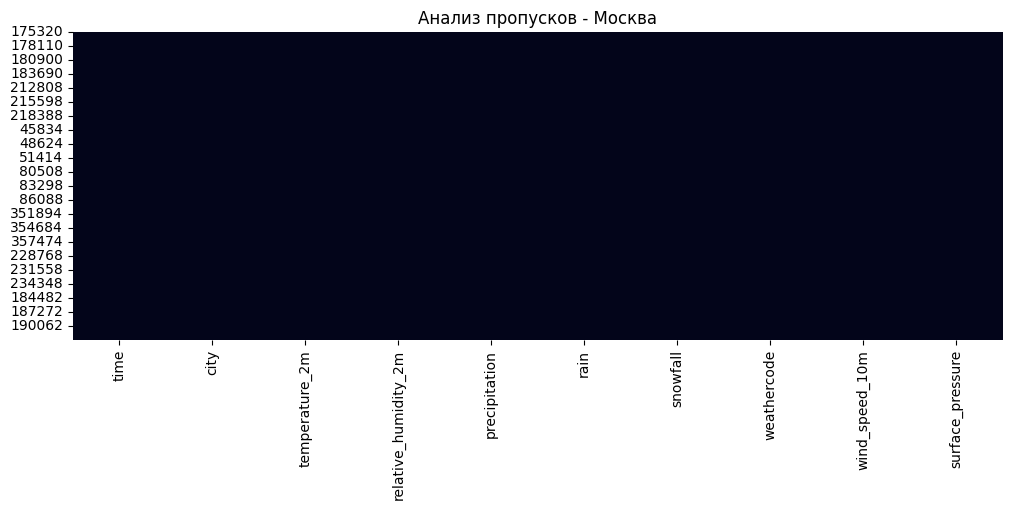

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


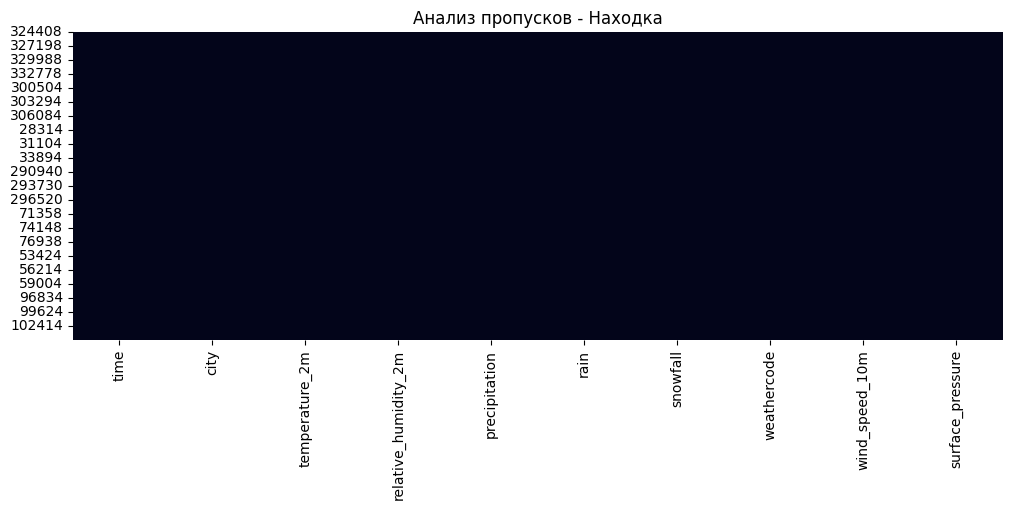

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


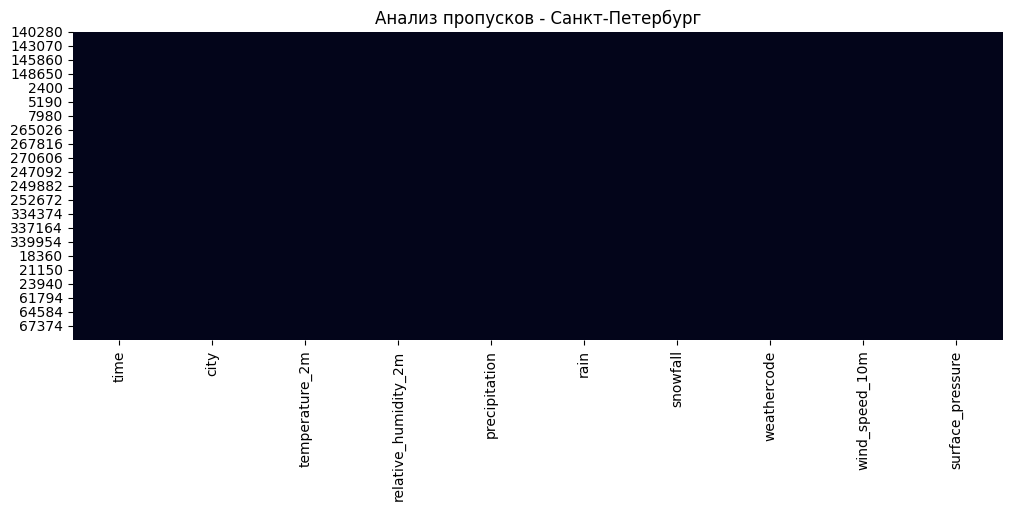

tmp.isna().sum(): time                    0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


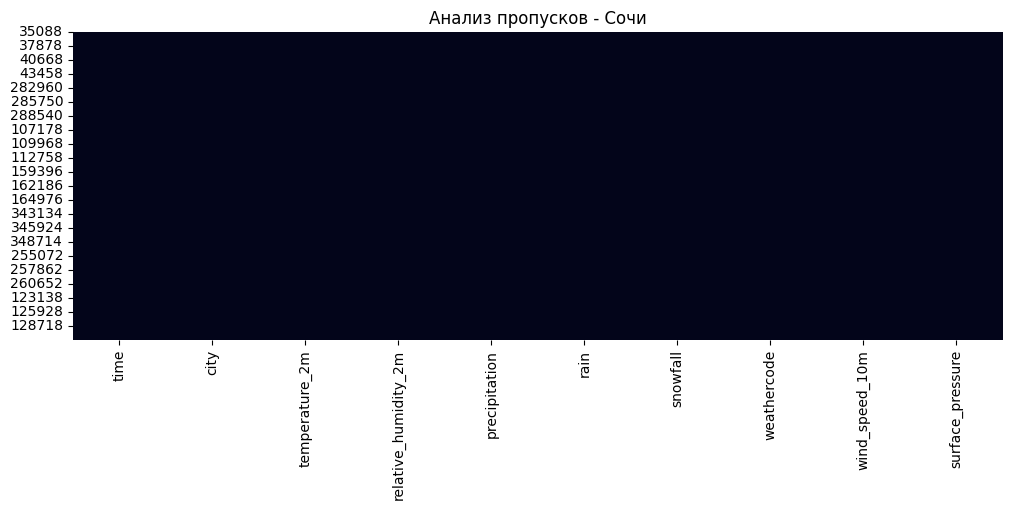

In [15]:
# проверка на пропуски
for city in cities:
  tmp = df[df["city"] == city]

  print(f"tmp.isna().sum(): {tmp.isna().sum()}")

  plt.figure(figsize=(12,4))
  sns.heatmap(tmp.isna(), cbar=False)
  plt.title(f"Анализ пропусков - {city}")
  plt.show()


Анализ пропусков показал, что во всех наборах данных отсутствуют пропущенные значения. Дополнительная обработка не требуется.

#### - Исследовать распределение каждого признака (гистограммы, box-plot, Q-Q plot для проверки нормальности)

Чтобы как-то сократить размерность, предлагается взять один город

In [16]:
#city: str = "Москва"
#tmp = df[df["city"] == city].copy()
cols: list[str] = columns.copy()
cols.remove("city")
cols.remove("time")
cols.remove("weathercode") # это категориальный признак

In [17]:

def plot_for_every_col(city: str) -> None:
    tmp: DataFrame = df[df["city"] == city].copy()
    n_cols: int = len(cols)

    fig, axes = plt.subplots(3, n_cols, figsize=(20, 8))
    for i_feature, col in enumerate(cols):

        sns.histplot(tmp[col], kde=True, ax=axes[0, i_feature])
        axes[0, i_feature].set_title(f"{col} - Распределение", size=6)
        axes[0, i_feature].tick_params(axis='both', labelsize=5)
        axes[0, i_feature].set_ylabel('Count', fontsize=5)

        sns.boxplot(x=tmp[col], ax=axes[1, i_feature])
        axes[1, i_feature].set_title(f"{col} - Выбросы", size=6)
        axes[1, i_feature].tick_params(axis='both', labelsize=5)

        stats.probplot(tmp[col].dropna(), dist="norm", plot=axes[2, i_feature])
        axes[2, i_feature].set_title(f"{col} - Q-Q", size=6)
        axes[2, i_feature].tick_params(axis='both', labelsize=5)

    plt.suptitle(f"Исследование распределения каждого признака - {city}")
    plt.subplots_adjust(hspace=1.0)
    plt.tight_layout()
    plt.show()

#city: str = "Москва"
#tmp = df[df["city"] == city].copy()


# n_cols: int = len(cols)

# fig, axes = plt.subplots(3, n_cols, figsize=(18, 6))
# for i_feature, col in enumerate(cols):

#     sns.histplot(df[col], kde=True, ax=axes[0, i_feature])
#     axes[0, i_feature].set_title(f"{col} - Распределение", size=6)
#     axes[0, i_feature].tick_params(axis='both', labelsize=5)
#     axes[0, i_feature].set_ylabel('Count', fontsize=5)

#     sns.boxplot(x=df[col], ax=axes[1, i_feature])
#     axes[1, i_feature].set_title(f"{col} - Выбросы", size=6)
#     axes[1, i_feature].tick_params(axis='both', labelsize=5)

#     stats.probplot(df[col].dropna(), dist="norm", plot=axes[2, i_feature])
#     axes[2, i_feature].set_title(f"{col} - Q-Q", size=6)
#     axes[2, i_feature].tick_params(axis='both', labelsize=5)

# plt.suptitle(f"Исследование распределения каждого признака - {city}")
# plt.subplots_adjust(hspace=1.0)
# plt.tight_layout()
# plt.show()


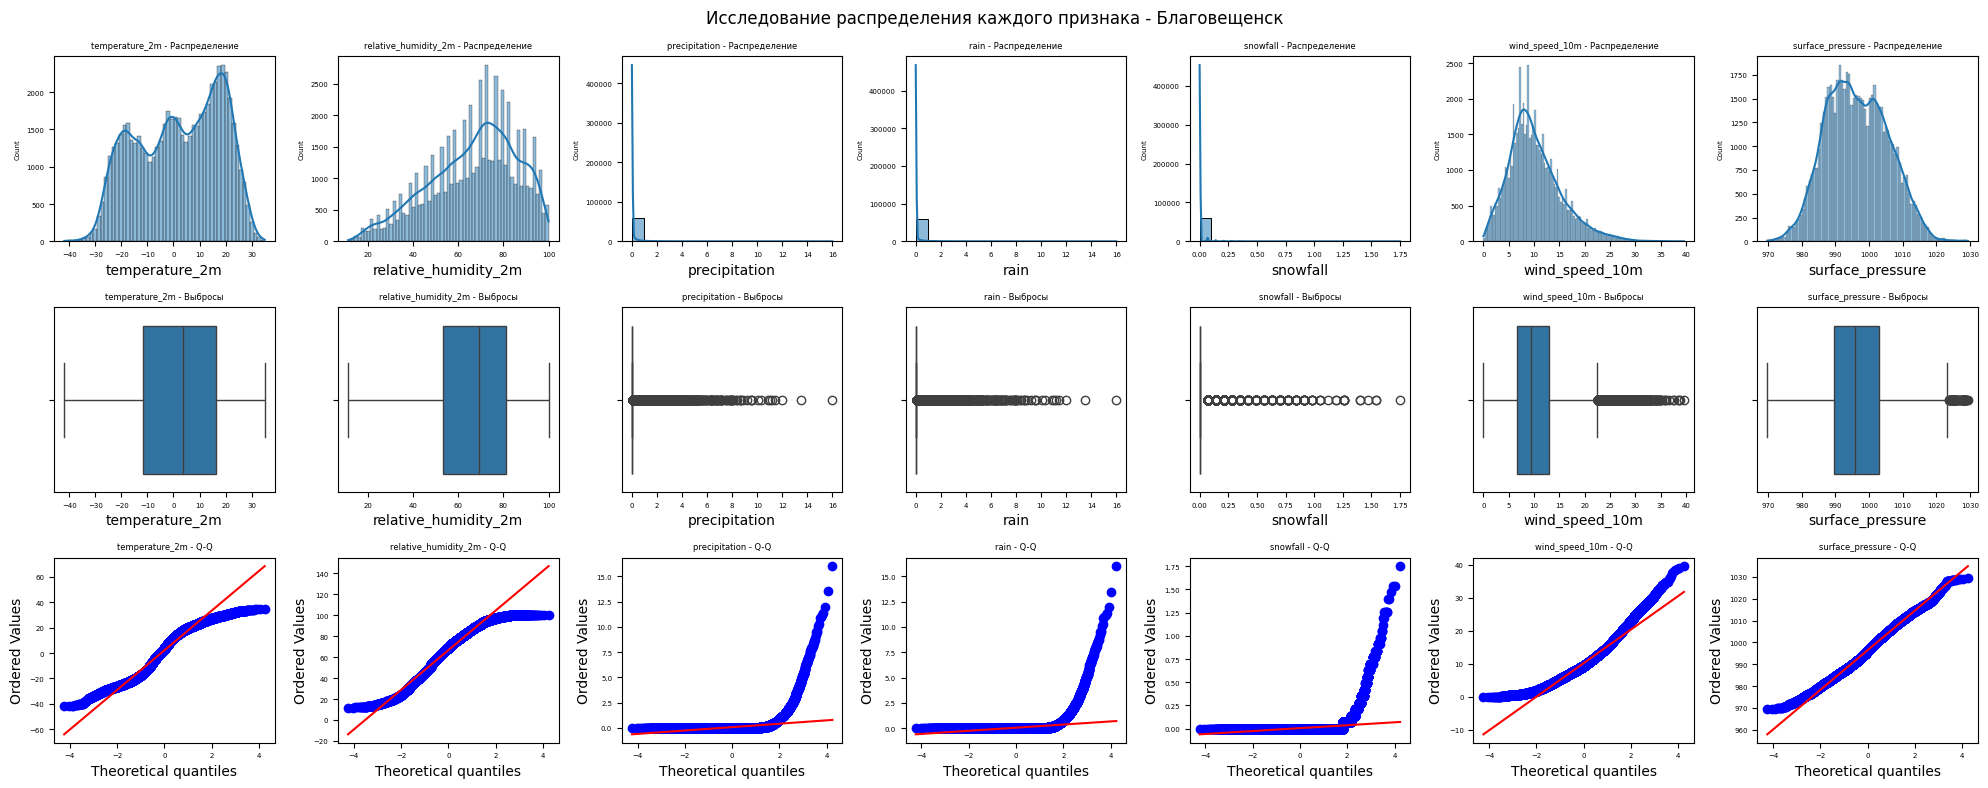

In [18]:
plot_for_every_col(city=cities[0])

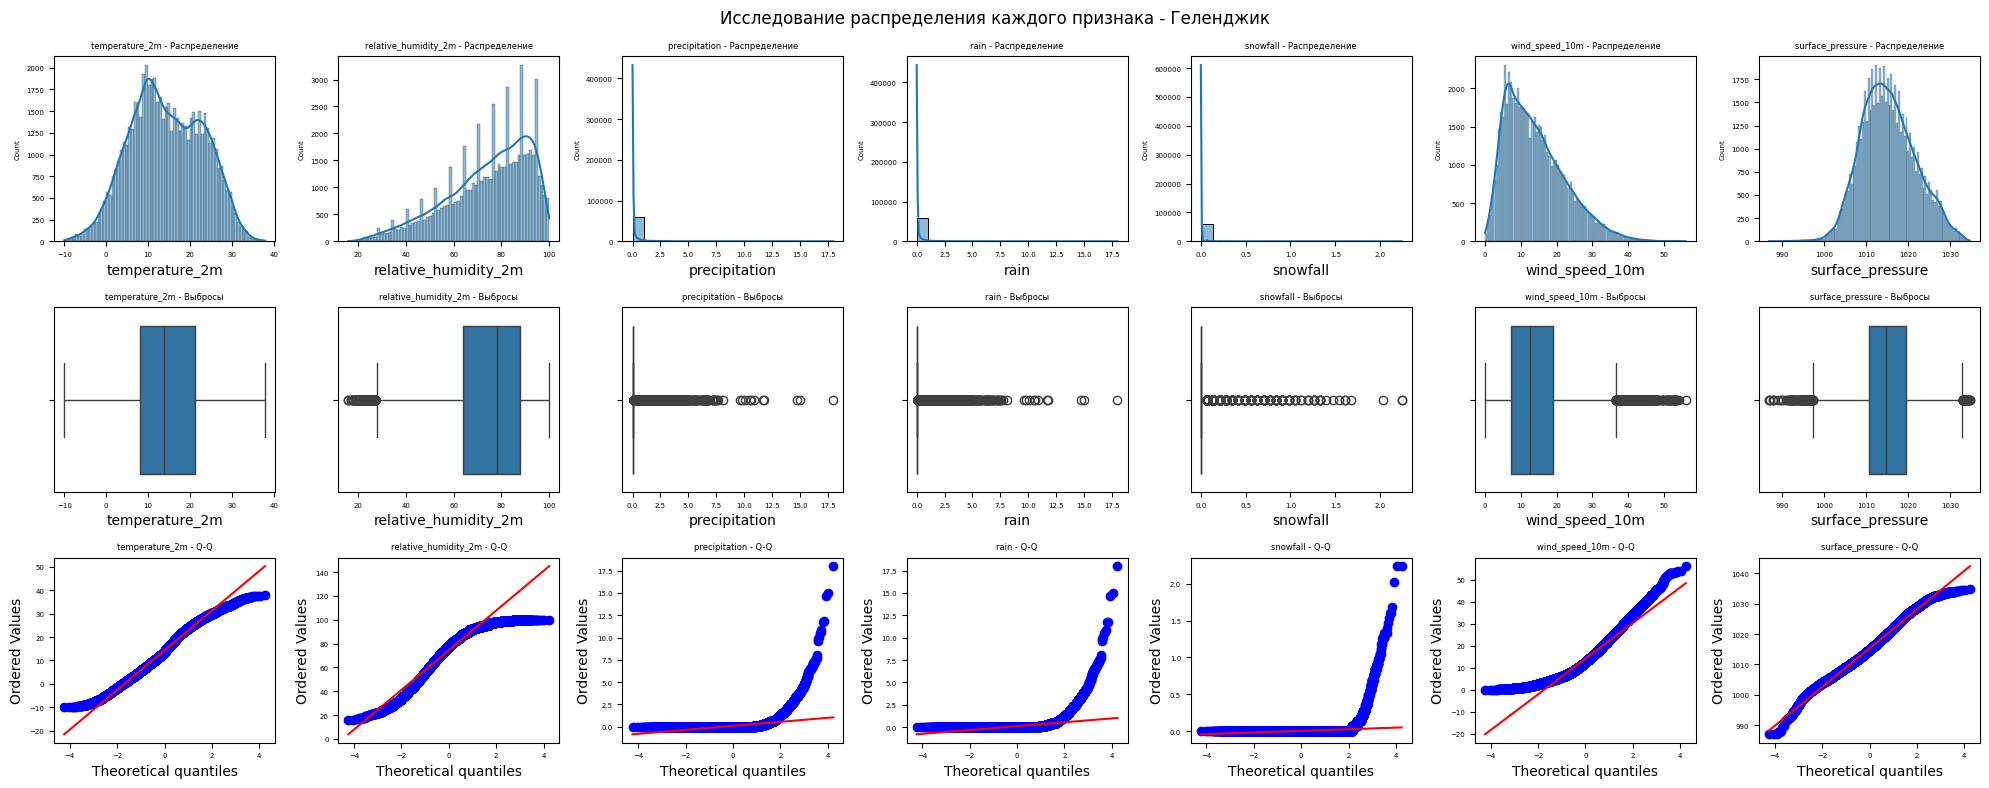

In [19]:
plot_for_every_col(city=cities[1])

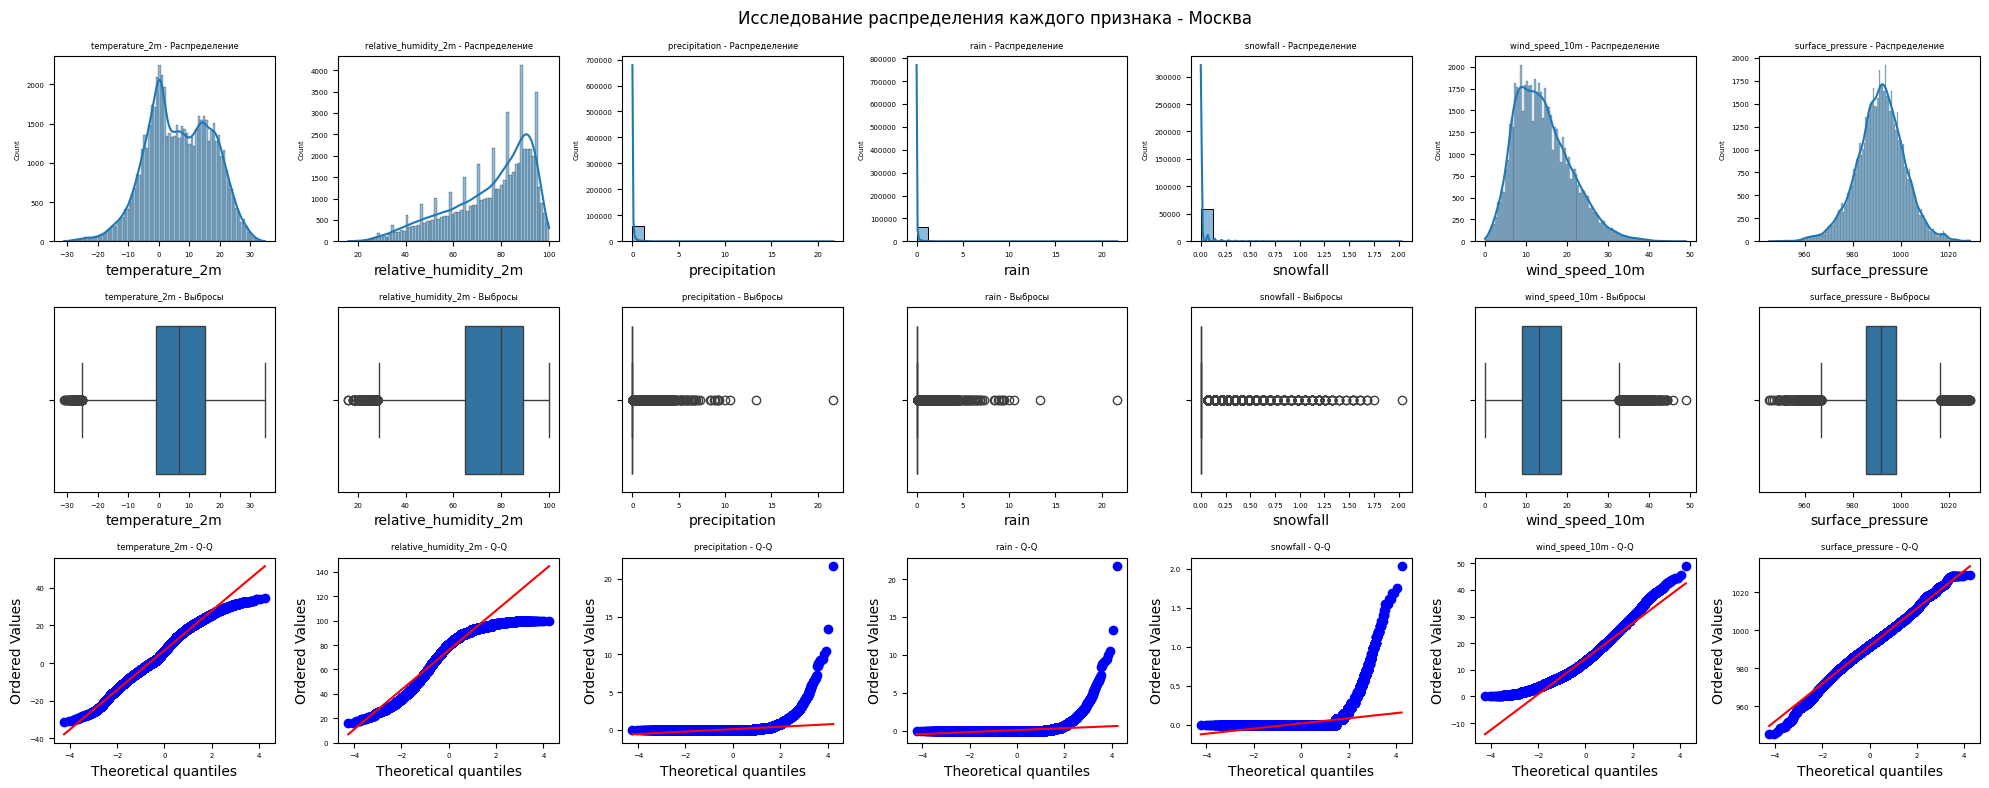

In [20]:
plot_for_every_col(city=cities[2])

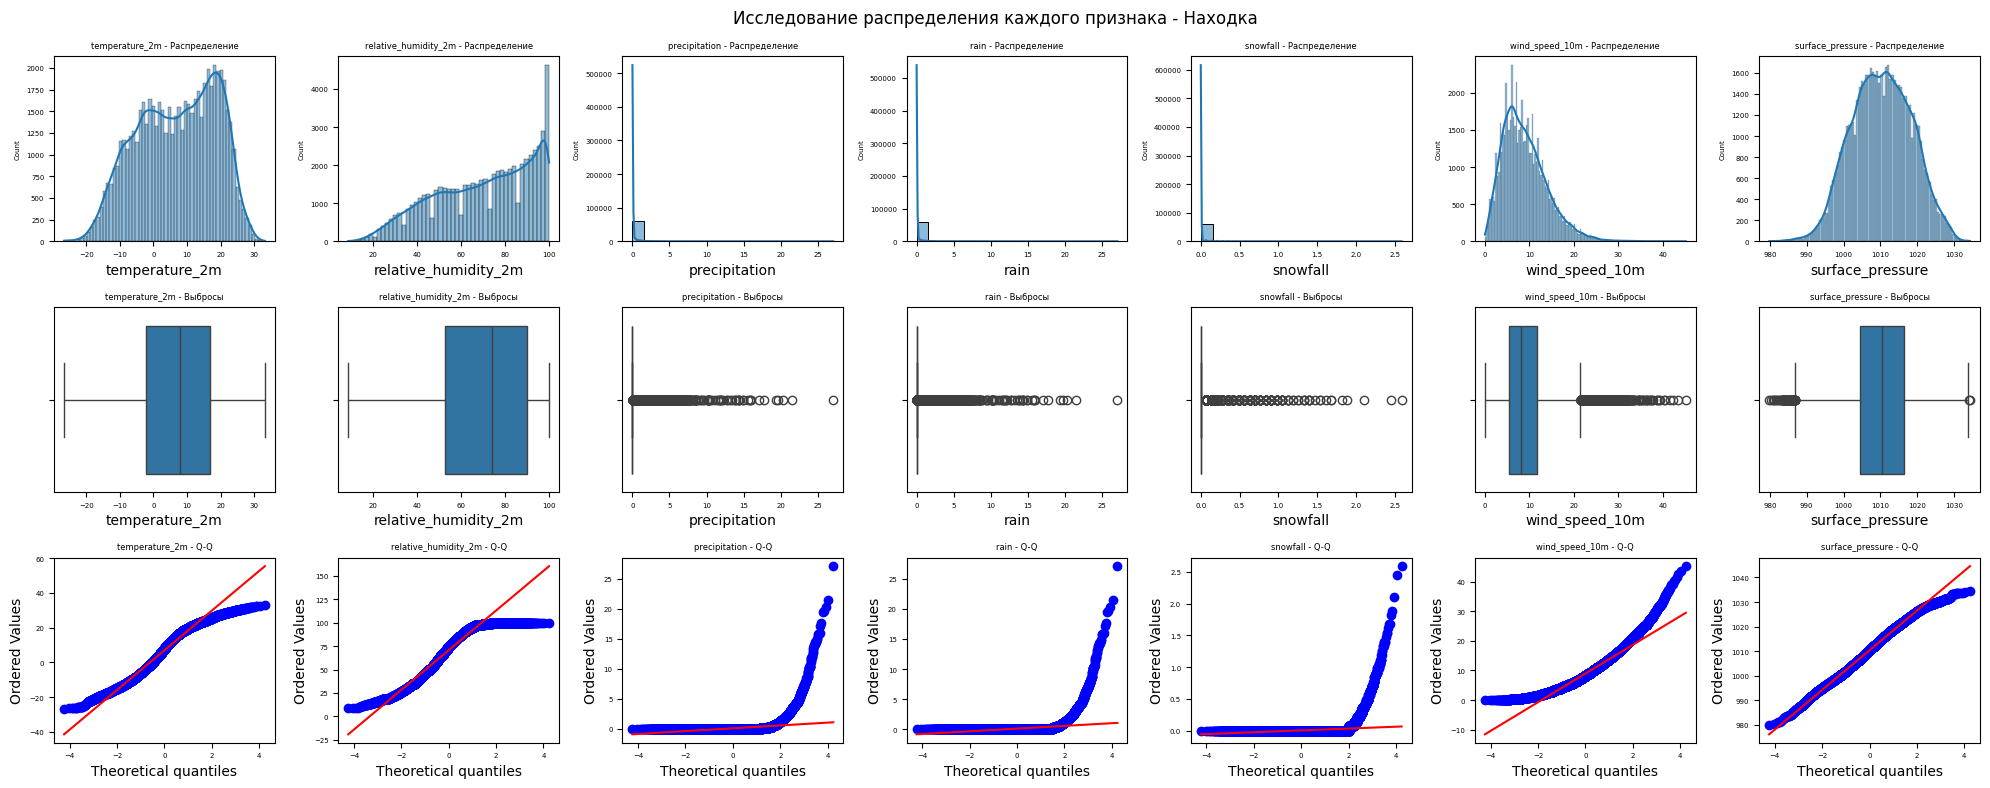

In [21]:
plot_for_every_col(city=cities[3])

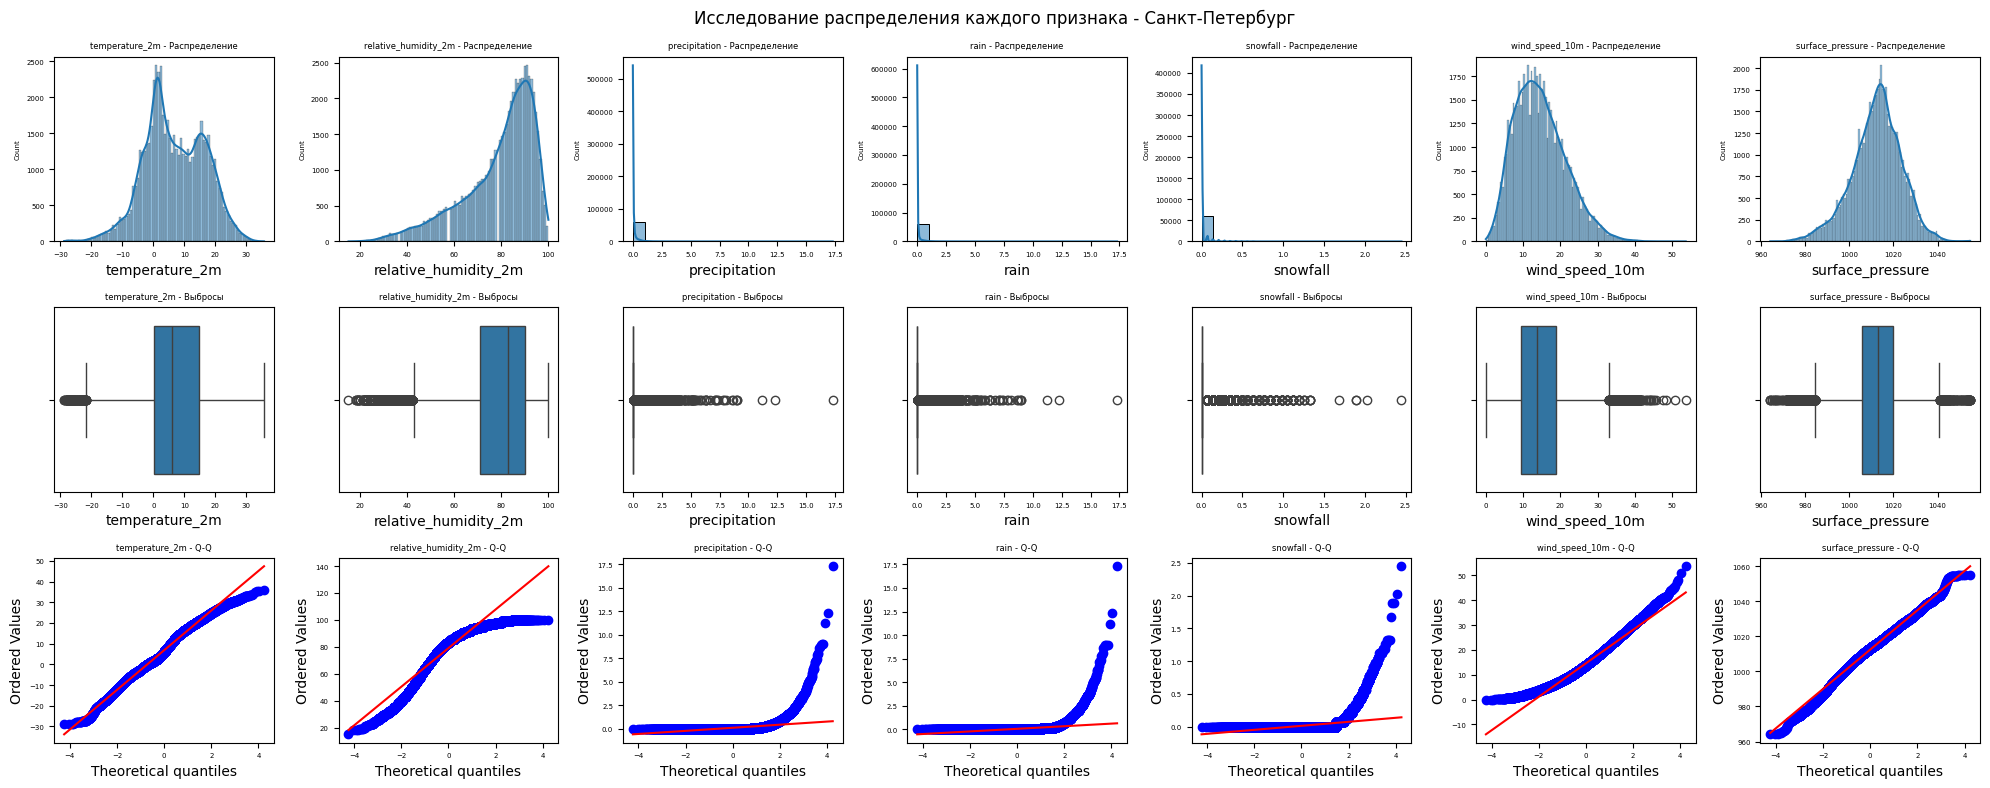

In [22]:
plot_for_every_col(city=cities[4])

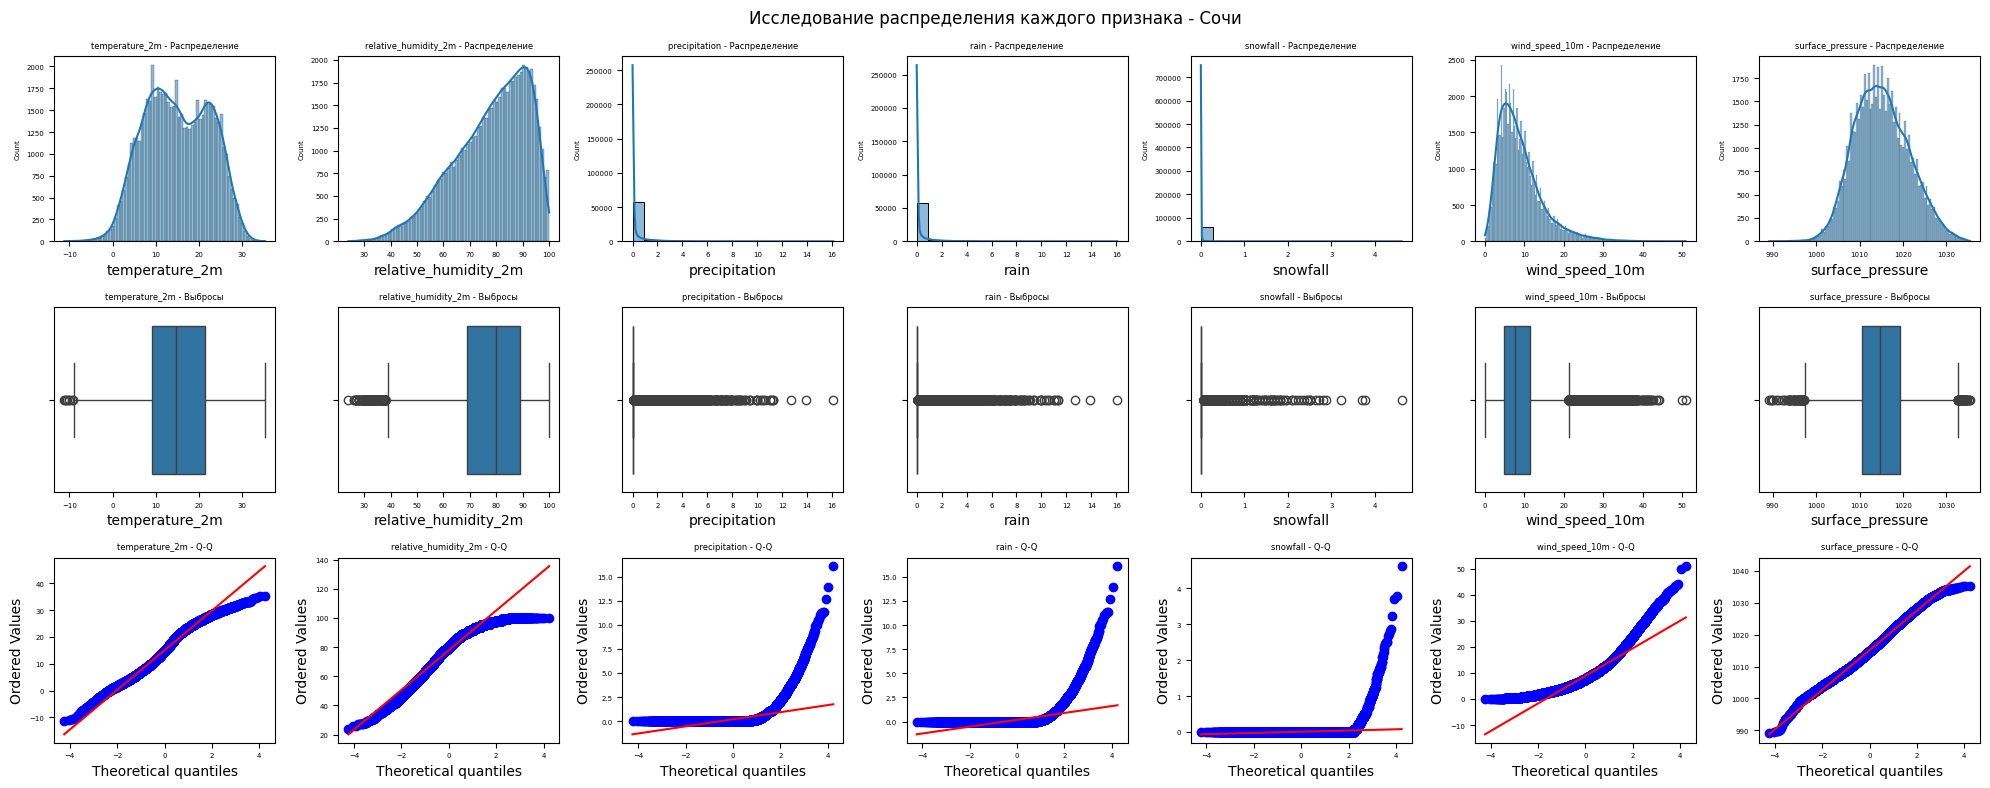

In [23]:
plot_for_every_col(city=cities[5])

In [24]:
# for col in cols:
#     plt.figure(figsize=(6,4))
#     sns.histplot(tmp[col], kde=True)
#     plt.title(f"Распределение колонки {col} - {city}")
#     plt.show()

# # box-plot выбросы
# for col in cols:
#     plt.figure(figsize=(6,2))
#     sns.boxplot(x=tmp[col])
#     plt.title(f"Выбросы {col} box-plot - {city}")
#     plt.show()

# import scipy.stats as stats

# # Q-Q plot
# for col in cols:
#     plt.figure(figsize=(5,5))
#     stats.probplot(tmp[col].dropna(), dist="norm", plot=plt)
#     plt.title(f"Q-Q plot - {col}")
#     plt.show()

**Гистограммы**

- temperature_2m

Распределение температуры является мультидальным, что обусловлено выраженной сезонностью, разделение на холодный и тёплый периоды в городах, кроме Благовещенска, в последнем возможно разделены на 3 сезон: зимний, весенне-осенний и летний - это будет уточнено дальше в данной лабораторной работе. Нормальное распределение не выполняется.

- relative_humidity_2m

Распределение относительной влажности асимметрично с концентрацией значений в верхнем диапазоне. Наблюдается отклонение от нормального распределения.

- (все садки) precipitation, rain, showfall

Распределение осадков имеет выраженную правостороннюю асимметрию с доминирующим значением нуля, пик в нуле почти у всех, и редкие всплески у снега. Данные не подчиняются нормальному распределению.

- weathercode

Признак weathercode является категориальным и не подчиняется нормальному распределению.

- wind_speed_10m

Скорость ветра имеет распределение, близкое к нормальному, однако наблюдается правосторонняя асимметрия полагается из-за редких сильных ветров.

- surface_pressure

Атмосферное давление демонстрирует распределение, близкое к нормальному, с незначительными отклонениями и редкими экстремальными значениями.

**Выбросы**

Выбросы присутствуют во всех признаках, однако они соответствуют реальным экстремальным погодным условиям и предлагается не рассматривать как ошибки измерений.

**Q-q plot**

Q-Q графики показывают, что большинство признаков отклоняются от нормального распределения, особенно в хвостах. Наиболее близкими к нормальному являются давление и скорость ветра.

---
Анализ распределений показал, что большинство метеорологических признаков не подчиняются нормальному распределению. Это связано с выраженной сезонностью (температура), ограничениями физических величин (влажность), а также разреженной структурой данных (осадки). Наиболее близкими к нормальному распределению являются атмосферное давление и скорость ветра.

#### - Выявить и визуализировать сезонные паттерны (по месяцам, по временам года)

In [25]:
df["month"] = df["time"].dt.month
df["season"] = df["time"].dt.month % 12 // 3 + 1

In [26]:
season_map = {
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Autumn"
}
df["season_name"] = df["season"].map(season_map)

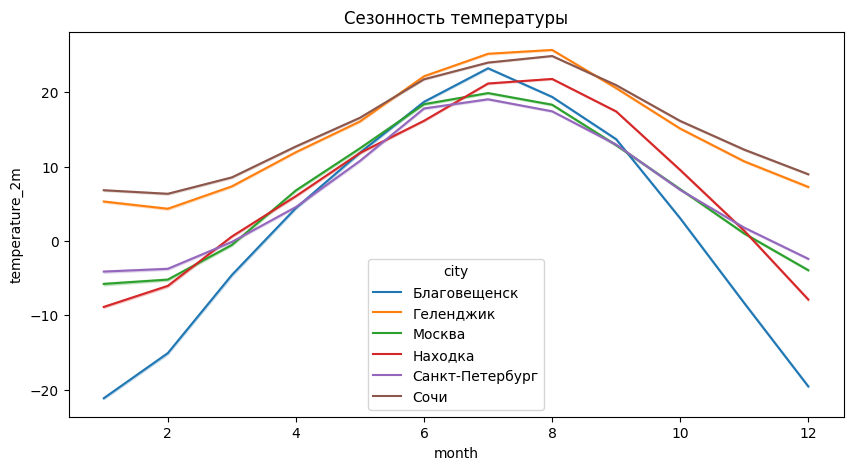

In [27]:
# сезонность температуры по месяцам
plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="month", y="temperature_2m", hue="city")

plt.title("Сезонность температуры")
plt.show()

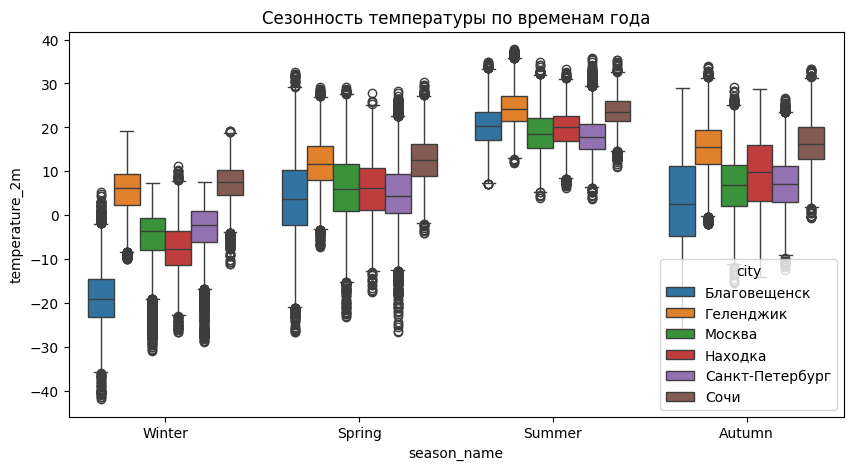

In [28]:
# сезонность по временам года
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x="season_name", y="temperature_2m", hue="city")
plt.title("Сезонность температуры по временам года")
plt.show()

Температура демонстрирует выраженную сезонную зависимость: минимальные значения наблюдаются зимой, максимальные — летом. Континентальные города характеризуются более резкими переходами между сезонами, в то время как прибрежные — более сглаженными.

Благовещенск имеет ниже температуру, чем у остальных городов, по причине расположен на Дальнем Востоке, где влияние холодной Сибири зимой сильнее, чем смягчающее влияние Тихого океана, что приводит к сильным морозам.

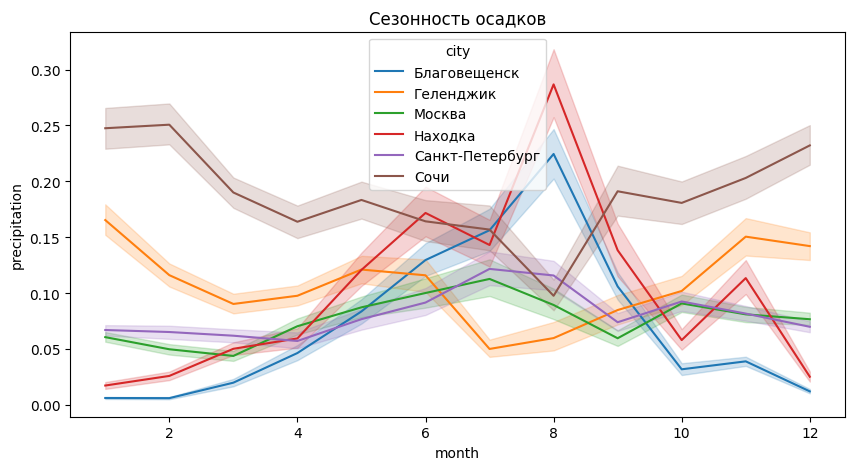

In [29]:
# сезонность осадков
plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="month", y="precipitation", hue="city")

plt.title("Сезонность осадков")
plt.show()

Сезонное распределение осадков различается между городами: резкий скачок приходится на лето у Благовещенска (из-за расположения в зоне резко континентального муссонного климата) и Находка (в основном из-за влияния океана), в других — распределён равномернее и летом меньше осадков, чем в другие времена года.

#### - Проанализировать корреляции между всеми признаками (тепловая карта корреляционной матрицы)

In [30]:
# корреляционная матрица
corr_all = df[cols].corr()

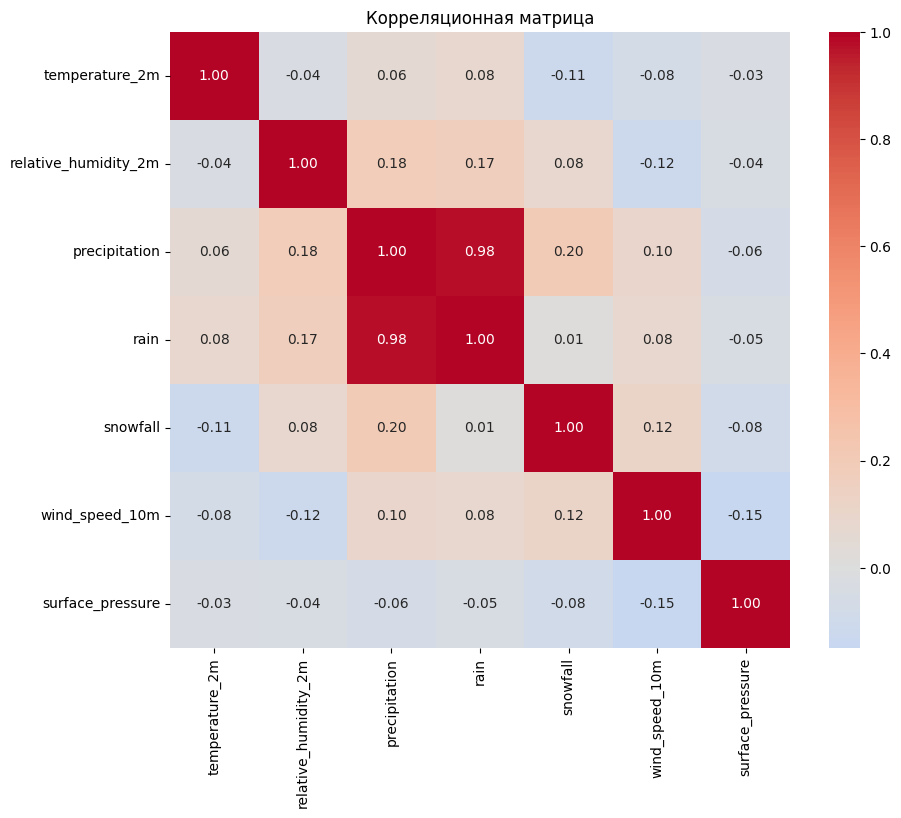

In [31]:
# корреляциооная матрица для всех городов
plt.figure(figsize=(10,8))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

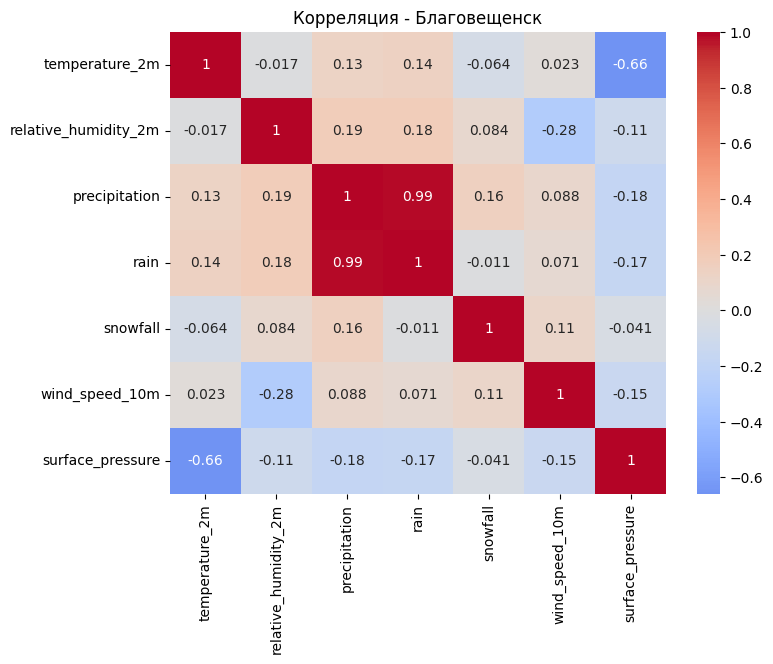

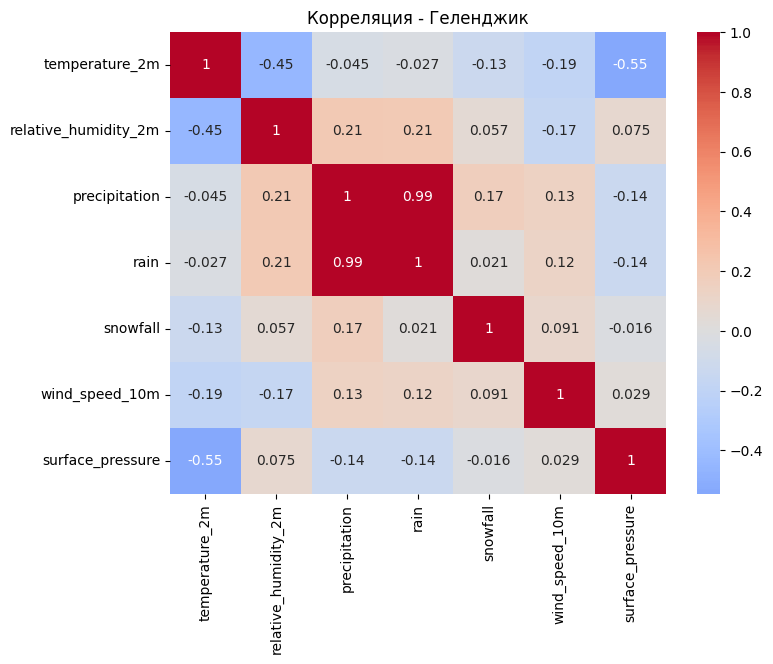

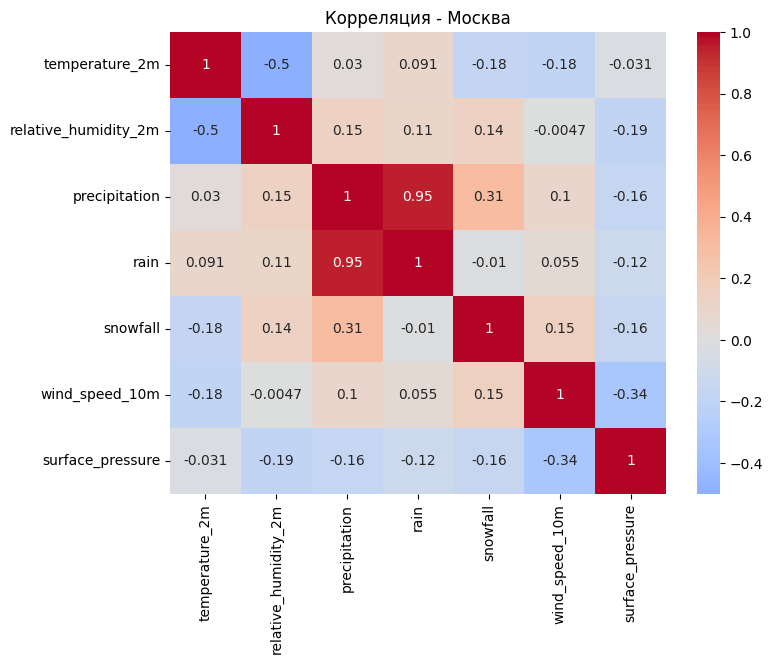

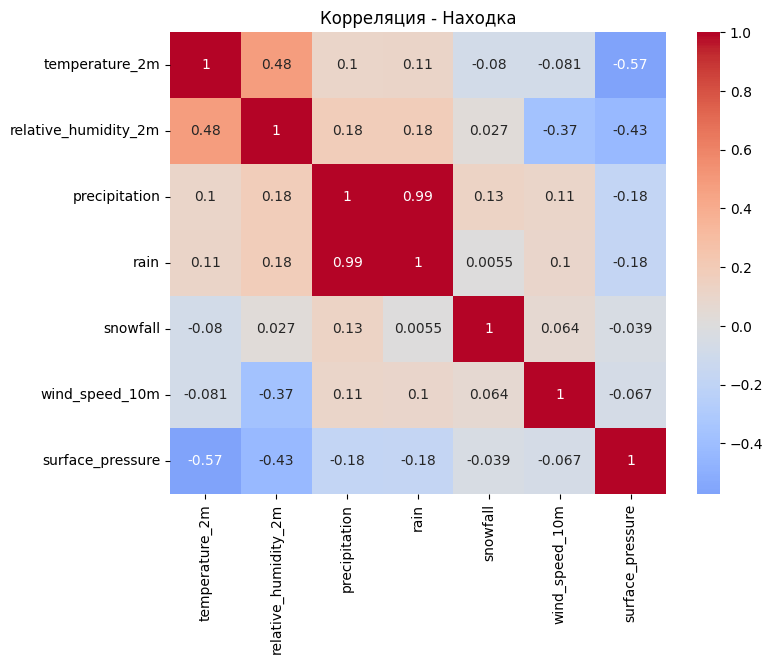

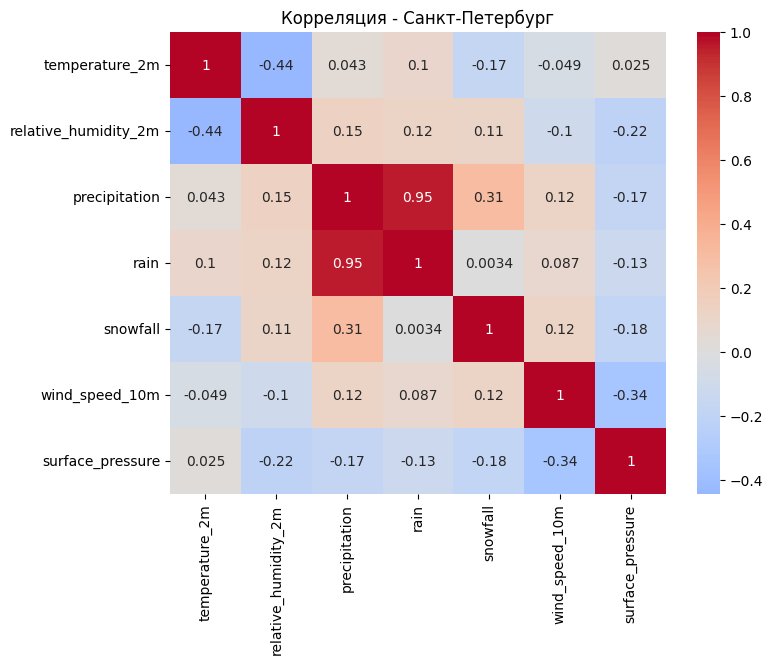

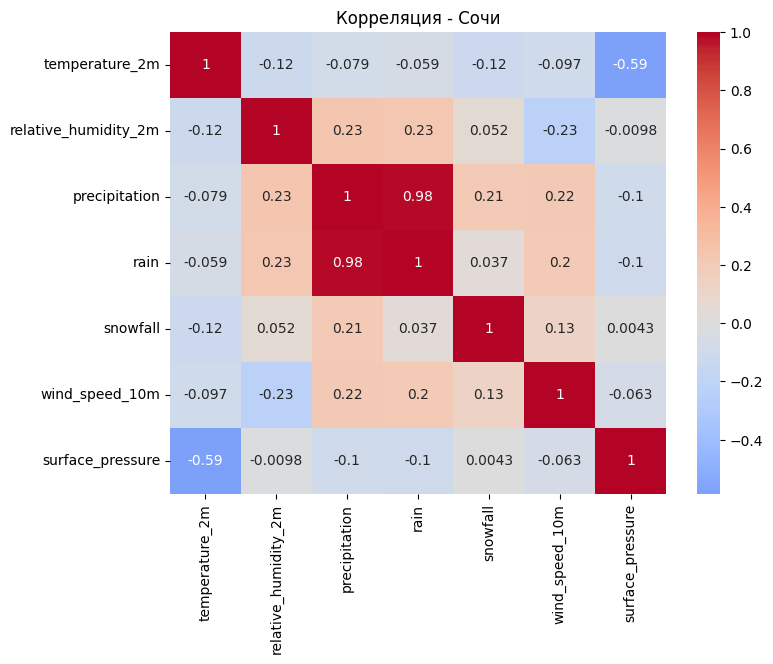

In [32]:
for city in cities:
    tmp = df[df["city"] == city]

    corr = tmp[cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.title(f"Корреляция - {city}")
    plt.show()

Температура демонстрирует отрицательную корреляцию с влажностью, что объясняется физическими процессами: при повышении температуры относительная влажность снижается.

Признаки precipitation, rain и snowfall демонстрируют сильную взаимосвязь, что указывает на их зависимость и потенциальную избыточность. Высокая корреляция между признаками precipitation и rain обусловлена тем, что precipitation включает в себя дождь как составную часть. Это указывает на избыточность информации. Для упрощения модели возможно исключение одного из признаков.

### Кросс-городской анализ:
#### - Сравнить распределения температуры и осадков между городами

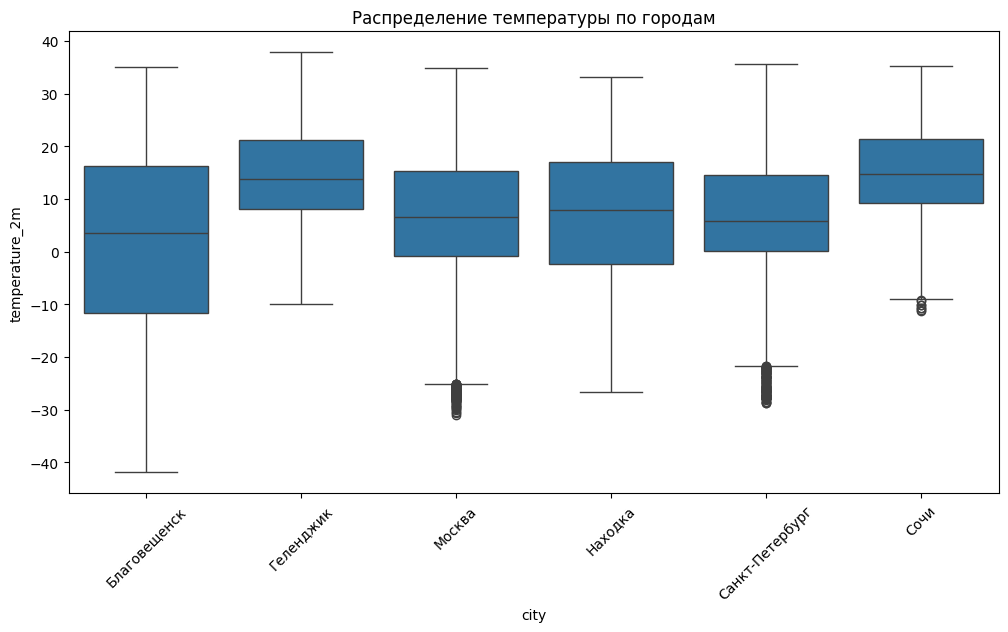

In [33]:
# температура
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="city", y="temperature_2m")

plt.title("Распределение температуры по городам")
plt.xticks(rotation=45)
plt.show()

Распределения температуры существенно различаются между городами. Южные города (Геленджик, Сочи) характеризуются более высокими средними температурами и меньшей вариативностью, тогда как континентальные регионы, особенно Благовещенск, демонстрируют более широкий диапазон температур.

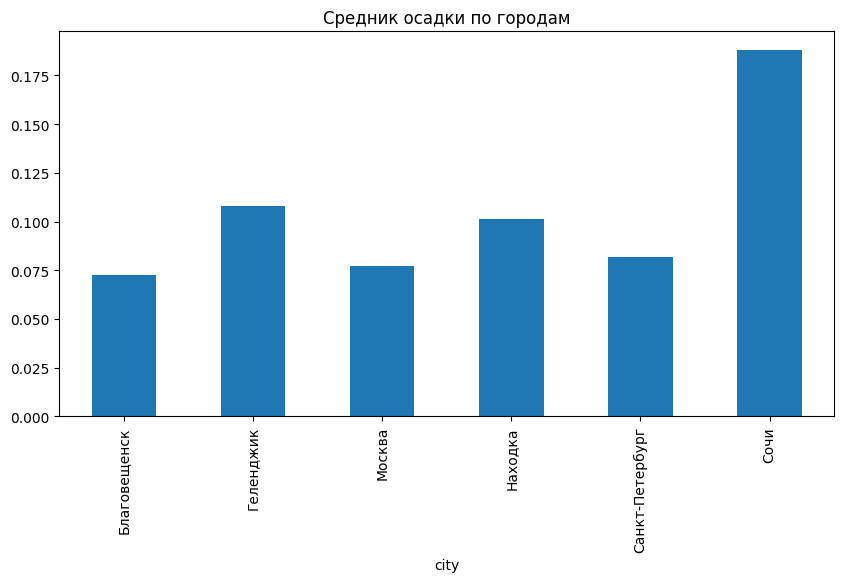

In [34]:

precipitation_mean = df.groupby("city")["precipitation"].mean()

precipitation_mean.plot(kind="bar", figsize=(10,5))
plt.title("Средник осадки по городам")
plt.show()

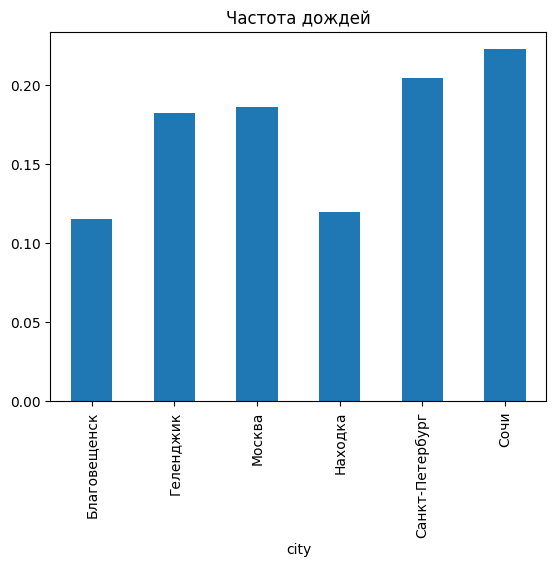

In [35]:
rain_days = df.groupby("city")["precipitation"].apply(lambda x: (x > 0).mean())

rain_days.plot(kind="bar")
plt.title("Частота дождей")
plt.show()

Распределение осадков существенно различается между городами. В прибрежных регионах (особенно Сочи) осадки наблюдаются чаще, тогда как в континентальных регионах они более редки, но могут быть интенсивнее.

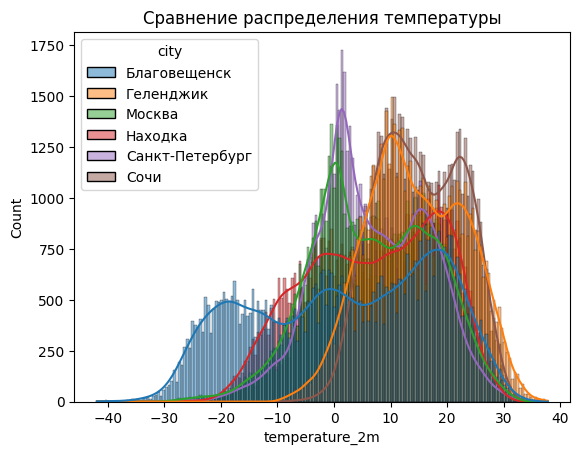

In [36]:
sns.histplot(data=df, x="temperature_2m", hue="city", kde=True)
plt.title("Сравнение распределения температуры")
plt.show()

Континентальный город Благовещенск выделается среди остальных более низкими температурами. Южные города (Геленджик и Сочи) характеризуются более высокими температурами.

#### - Визуализировать климатические профили городов (среднемесячные температуры, среднегодовые осадки)

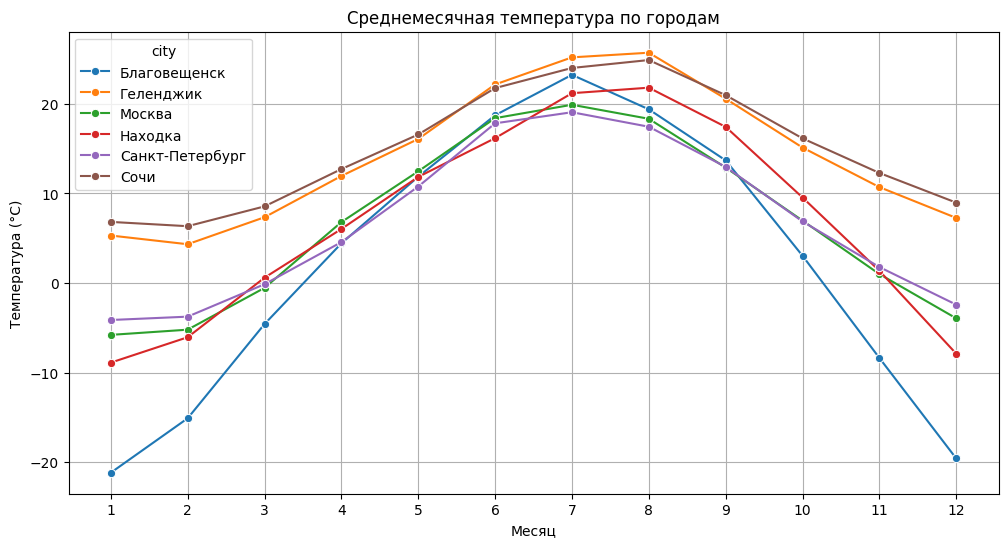

In [37]:
# Среднемесячная температура
monthly_temp = (
    df.groupby(["city", "month"])["temperature_2m"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(data=monthly_temp, x="month", y="temperature_2m", hue="city", marker="o")

plt.title("Среднемесячная температура по городам")
plt.xlabel("Месяц")
plt.ylabel("Температура (°C)")
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

Анализ уже делался выше в сезонности температур.

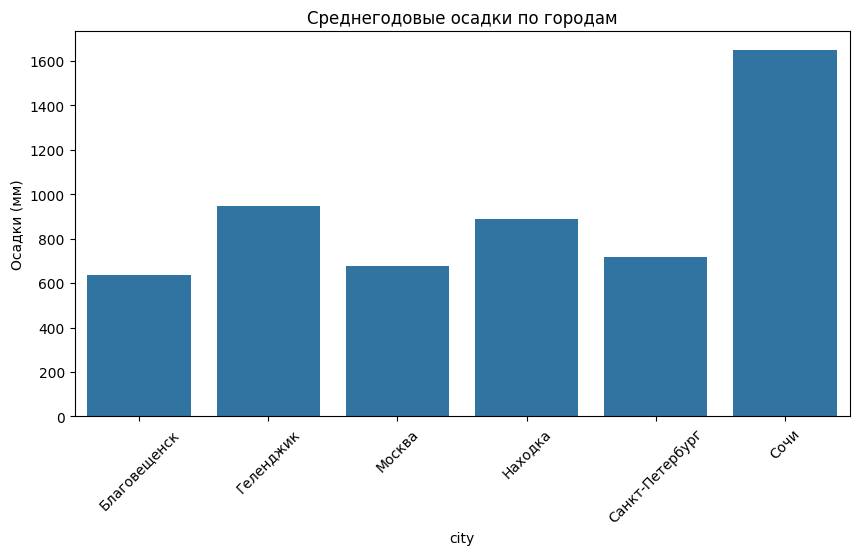

In [38]:
# Среднегодовые осадки
yearly_precip = (
    df.groupby(["city", df["time"].dt.year])["precipitation"]
    .sum()
    .reset_index(name="year_precip")
)
yearly_mean_precip = (
    yearly_precip.groupby("city")["year_precip"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(data=yearly_mean_precip, x="city", y="year_precip")

plt.title("Среднегодовые осадки по городам")
plt.ylabel("Осадки (мм)")
plt.xticks(rotation=45)

plt.show()

Среднегодовые осадки сильно различаются между городами, предположительно обусловлено климатические особенности регионов. Прибрежные города характеризуются более высоким уровнем осадков.

#### - Выявить аномалии и выбросы в межгородском сравнении

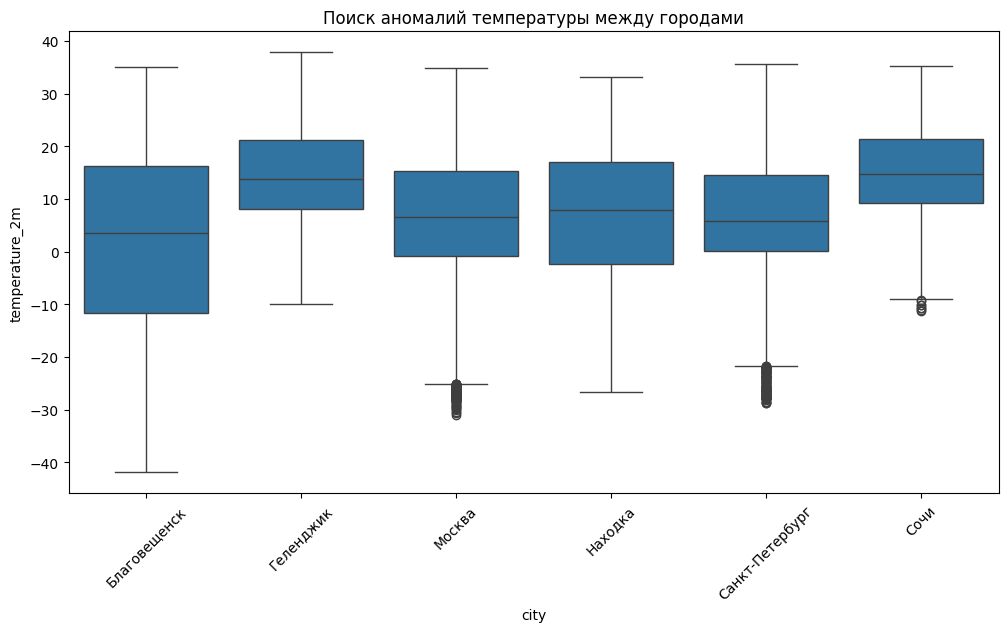

In [39]:
# поиск аномалий температуры между городами
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="city", y="temperature_2m")

plt.title("Поиск аномалий температуры между городами")
plt.xticks(rotation=45)
plt.show()

Несмотря на наличие выбросов в распределениях температуры для Москвы и Санкт-Петербурга, они соответствуют умеренным отклонениям относительно локального климата.

Благовещенск демонстрирует более экстремальные абсолютные значения температуры, что обусловлено континентальным климатом.

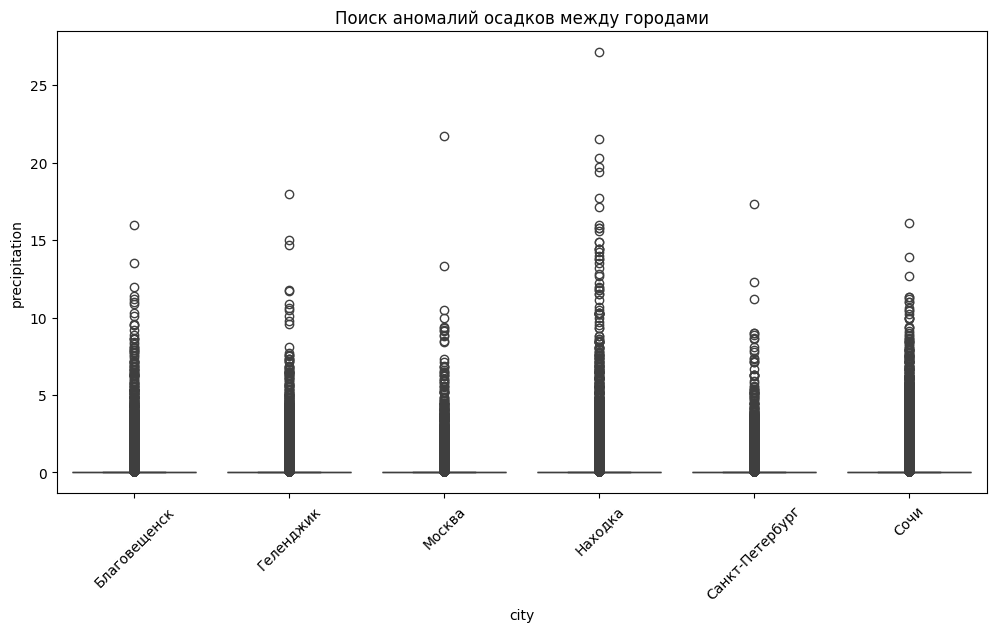

In [40]:
# поиск аномалий осадков между городами
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="city", y="precipitation")

plt.title("Поиск аномалий осадков между городами")
plt.xticks(rotation=45)
plt.show()

Несмотря на то, что среднегодовые осадки в Сочи выше, распределение осадков в Находке характеризуется большей вариативностью и наличием экстремальных значений. Это свидетельствует о различиях в характере осадков: в Сочи они более равномерные, тогда как в Находке наблюдаются редкие, но интенсивные осадки (ливни, тайфуны).

Значения для остальных городов находятся в умеренных значениях.

#### - Провести анализ пропусков: определить характер пропусков, предложить стратегию их обработки
Задание выполнял выше, пропусков в данных замечено не было.

In [41]:
df.isna().sum()

,0
time,0
city,0
temperature_2m,0
relative_humidity_2m,0
precipitation,0
rain,0
snowfall,0
weathercode,0
wind_speed_10m,0
surface_pressure,0


### Анализ стационарности:
#### - Проверить ряды на стационарность (тест Дики-Фуллера) для каждого города

In [42]:
from statsmodels.tsa.stattools import adfuller

In [43]:
for city in df["city"].unique():
    tmp = df[df["city"] == city].sort_values("time")

    result = adfuller(tmp["temperature_2m"])

    print(f"Город: {city}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("-------------------------------------------------------------------------")

Город: Благовещенск
ADF Statistic: -3.8911467514848717
p-value: 0.0021009769013634744
-------------------------------------------------------------------------
Город: Геленджик
ADF Statistic: -6.859243115346752
p-value: 1.6183956375838147e-09
-------------------------------------------------------------------------
Город: Москва
ADF Statistic: -6.219241013514505
p-value: 5.27271807887915e-08
-------------------------------------------------------------------------
Город: Находка
ADF Statistic: -4.938233364948005
p-value: 2.9365980726620822e-05
-------------------------------------------------------------------------
Город: Санкт-Петербург
ADF Statistic: -6.042208542761229
p-value: 1.3376366273033465e-07
-------------------------------------------------------------------------
Город: Сочи
ADF Statistic: -6.407561386547782
p-value: 1.9263597836558336e-08
-------------------------------------------------------------------------


Для проверки стационарности временных рядов температуры был применен тест Дики-Фуллера. Для всех городов получены значения p-value ниже 0.05, что формально свидетельствует о стационарности рядов.

Однако визуальный анализ показывает наличие выраженной сезонности (годовой и суточной), что указывает на сомнения рациональности применения теста в данном случае.

#### - Применить дифференцирование для приведения к стационарному виду при необходимости
Случайно пропустил и дальше эти действия делал, позже к этому пункту вернулся.

In [44]:
df.shape

(368208, 13)

In [45]:
df["temp_diff_1"] = df.groupby("city")["temperature_2m"].diff()
df["temp_diff_24"] = df.groupby("city")["temperature_2m"].diff(24)
df["temp_diff_168"] = df.groupby("city")["temperature_2m"].diff(24*7)

In [46]:
df.head()

,time,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,month,season,season_name,temp_diff_1,temp_diff_24,temp_diff_168
271800,2019-01-01 00:00:00,Благовещенск,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012,1,1,Winter,NaN,NaN,NaN
271801,2019-01-01 01:00:00,Благовещенск,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000,1,1,Winter,0.500000,NaN,NaN
271802,2019-01-01 02:00:00,Благовещенск,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988,1,1,Winter,0.700000,NaN,NaN
271803,2019-01-01 03:00:00,Благовещенск,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024,1,1,Winter,0.400000,NaN,NaN
271804,2019-01-01 04:00:00,Благовещенск,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000,1,1,Winter,0.200001,NaN,NaN


In [47]:
#df = df.dropna(subset=["temp_diff_24"])

In [48]:
#df.shape

In [49]:
"""
for city in df["city"].unique():
    tmp = df[df["city"] == city].sort_values("time")

    result = adfuller(tmp["temperature_2m"])

    print(f"Город: {city}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("-------------------------------------------------------------------------")
"""

'\nfor city in df["city"].unique():\n    tmp = df[df["city"] == city].sort_values("time")\n\n    result = adfuller(tmp["temperature_2m"])\n\n    print(f"Город: {city}")\n    print(f"ADF Statistic: {result[0]}")\n    print(f"p-value: {result[1]}")\n    print("-------------------------------------------------------------------------")\n'

Для ускорения, вышло похожее максимально

Город: Благовещенск

ADF Statistic: -3.8911467514848717

p-value: 0.0021009769013634744

-------------------------------------------------------------------------
Город: Геленджик

ADF Statistic: -6.859243115346752

p-value: 1.6183956375838147e-09

-------------------------------------------------------------------------
Город: Москва

ADF Statistic: -6.219241013514505

p-value: 5.27271807887915e-08

-------------------------------------------------------------------------
Город: Находка

ADF Statistic: -4.938233364948005

p-value: 2.9365980726620822e-05

-------------------------------------------------------------------------
Город: Санкт-Петербург

ADF Statistic: -6.042208542761229

p-value: 1.3376366273033465e-07

-------------------------------------------------------------------------
Город: Сочи

ADF Statistic: -6.407561386547782

p-value: 1.9263597836558336e-08

-------------------------------------------------------------------------

Для приведения временных рядов к стационарному виду было применено дифференцирование. Рассматривались как обычные разности (первого порядка), так и сезонные разности с лагом 24 часа.

#### - Обосновать выбор методов обработки нестационарности в контексте прогнозирования
Временные ряды метеорологических данных характеризуются нестационарностью, обусловленной наличием трендов и выраженной сезонности. Несмотря на результаты теста Дики-Фуллера, визуальный анализ показал наличие суточных и годовых циклов.

Для приведения рядов к стационарному виду было применено дифференцирование первого порядка, позволяющее устранить тренд. Дополнительно использовалось сезонное дифференцирование с лагом 24 часа для учета суточной сезонности.

Также были сформированы лаговые признаки и скользящие статистики, позволяющие учитывать временные зависимости и сглаживать краткосрочные колебания. Такой подход позволяет повысить качество прогнозирования и устойчивость моделей.


---------------------------------------------

### Обосновать:
#### - Выбор метода интерполяции пропусков в контексте метеоданных
#### - Стратегию обработки выбросов (с учетом возможности экстремальных погодных явлений)
#### - Необходимость ресемплинга данных к единой временной частоте

В исходных данных пропущенные значения отсутствуют, поэтому методы интерполяции не применялись.

Выбросы не удалялись, так как они соответствуют реальным экстремальным погодным условиям и несут важную информацию о климате.

Данные уже представлены с единой временной частотой, поэтому дополнительный ресемплинг не требуется.

### 2.2. Инжиниринг признаков для временных рядов
#### Временные признаки:
#### - Извлечь из временного индекса: час, день недели, день месяца, месяц, сезон, год

In [50]:
df.head()

,time,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,month,season,season_name,temp_diff_1,temp_diff_24,temp_diff_168
271800,2019-01-01 00:00:00,Благовещенск,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012,1,1,Winter,NaN,NaN,NaN
271801,2019-01-01 01:00:00,Благовещенск,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000,1,1,Winter,0.500000,NaN,NaN
271802,2019-01-01 02:00:00,Благовещенск,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988,1,1,Winter,0.700000,NaN,NaN
271803,2019-01-01 03:00:00,Благовещенск,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024,1,1,Winter,0.400000,NaN,NaN
271804,2019-01-01 04:00:00,Благовещенск,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000,1,1,Winter,0.200001,NaN,NaN


In [51]:
# сезон расставлял выше
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek   # 0 = Понедельник
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year

#### - Создать циклические признаки (sin/cos) для часа и месяца для учета циклического характера времени

In [52]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [53]:
df.head()

,time,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,hour,day_of_week,day,year,month_sin,month_cos,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
271800,2019-01-01 00:00:00,Благовещенск,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012,...,0,1,1,2019,0.5,0.866025,0.000000,1.000000,0.781831,0.62349
271801,2019-01-01 01:00:00,Благовещенск,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000,...,1,1,1,2019,0.5,0.866025,0.258819,0.965926,0.781831,0.62349
271802,2019-01-01 02:00:00,Благовещенск,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988,...,2,1,1,2019,0.5,0.866025,0.500000,0.866025,0.781831,0.62349
271803,2019-01-01 03:00:00,Благовещенск,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024,...,3,1,1,2019,0.5,0.866025,0.707107,0.707107,0.781831,0.62349
271804,2019-01-01 04:00:00,Благовещенск,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000,...,4,1,1,2019,0.5,0.866025,0.866025,0.500000,0.781831,0.62349


### Лаговые признаки
Предполагается имеется ввиду температуры

In [54]:
df = df.sort_values(["city", "time"])

# температура
df["temp_lag_1"] = df.groupby("city")["temperature_2m"].shift(1)
df["temp_lag_24"] = df.groupby("city")["temperature_2m"].shift(24)
df["temp_lag_168"] = df.groupby("city")["temperature_2m"].shift(24*7)

# давление
df["pressure_lag_1"] = df.groupby("city")["surface_pressure"].shift(1)
df["pressure_lag_24"] = df.groupby("city")["surface_pressure"].shift(24)
df["pressure_lag_168"] = df.groupby("city")["surface_pressure"].shift(24*7)

# ветер
df["wind_lag_1"] = df.groupby("city")["wind_speed_10m"].shift(1)
df["wind_lag_24"] = df.groupby("city")["wind_speed_10m"].shift(24)
df["wind_lag_168"] = df.groupby("city")["wind_speed_10m"].shift(24*7)

In [55]:
#df.shape

In [56]:
#df = df.dropna()

In [57]:
#df.shape

Для учета временной зависимости были созданы лаговые признаки, отражающие значения температуры и давления в предыдущие моменты времени
- 1 час,
- 24 часа,
- 7 дней.

Это позволяет модели учитывать автокорреляцию временных рядов.

### Скользящие статистики

In [58]:
df["temp_roll_mean_24"] = (df.groupby("city")["temperature_2m"].transform(lambda x: x.rolling(24).mean()))
df["temp_roll_std_24"] = (df.groupby("city")["temperature_2m"].transform(lambda x: x.rolling(24).std()))
df["temp_roll_mean_168"] = (df.groupby("city")["temperature_2m"].transform(lambda x: x.rolling(24*7).mean()))

df["pressure_roll_mean_24"] = (df.groupby("city")["surface_pressure"].transform(lambda x: x.rolling(24).mean()))
df["pressure_roll_std_24"] = (df.groupby("city")["surface_pressure"].transform(lambda x: x.rolling(24).std()))
df["pressure_roll_mean_168"] = (df.groupby("city")["surface_pressure"].transform(lambda x: x.rolling(24*7).mean()))

df["wind_roll_mean_24"] = (df.groupby("city")["wind_speed_10m"].transform(lambda x: x.rolling(24).mean()))
df["wind_roll_std_24"] = (df.groupby("city")["wind_speed_10m"].transform(lambda x: x.rolling(24).std()))
df["wind_roll_mean_168"] = (df.groupby("city")["wind_speed_10m"].transform(lambda x: x.rolling(24*7).mean()))

Для сглаживания временных рядов и учета локальных трендов были рассчитаны скользящие статистики (среднее, стандартное отклонение) по окнам различной длины. Это позволяет учитывать краткосрочные и долгосрочные изменения параметров.

### Признаки динамики:
#### - Вычислить производные (скорость изменения температуры: разница между текущим и предыдущим значением)

In [59]:
df = df.sort_values(["city", "time"])

In [60]:
# температура
df["temp_diff_1"] = (df.groupby("city")["temperature_2m"].diff())
df["temp_diff_24"] = (df.groupby("city")["temperature_2m"].diff(24))
df["temp_diff_168"] = (df.groupby("city")["temperature_2m"].diff(24*7))

# давление
df["pressure_diff_1"] = df.groupby("city")["surface_pressure"].diff()
df["pressure_diff_24"] = df.groupby("city")["surface_pressure"].diff(24)
df["pressure_diff_168"] = df.groupby("city")["surface_pressure"].diff(24*7)

# ветер
df["wind_diff_1"] = df.groupby("city")["wind_speed_10m"].diff()
df["wind_diff_24"] = df.groupby("city")["wind_speed_10m"].diff(24)
df["wind_diff_168"] = df.groupby("city")["wind_speed_10m"].diff(24*7)

In [61]:
#df = df.dropna()

In [62]:
#df.shape

Для учета динамики изменения температуры, давления, скорости ветра были рассчитаны разностные признаки (производные), отражающие изменение значения между текущим и предыдущим моментами времени. Это позволяет учитывать скорость изменения параметров и выявлять резкие колебания, что важно для прогнозирования погодных условий.

#### - Вычислить ускорение (разница скоростей)

In [63]:
# температура
df["temp_acc_1"] = df.groupby("city")["temp_diff_1"].diff()
df["temp_acc_24"] = df.groupby("city")["temp_diff_24"].diff()
df["temp_acc_168"] = df.groupby("city")["temp_diff_168"].diff()

# давление
df["pressure_acc_1"] = df.groupby("city")["pressure_diff_1"].diff()
df["pressure_acc_24"] = df.groupby("city")["pressure_diff_24"].diff()
df["pressure_acc_168"] = df.groupby("city")["pressure_diff_168"].diff()

# ветер
df["wind_acc_1"] = df.groupby("city")["wind_diff_1"].diff()
df["wind_acc_24"] = df.groupby("city")["wind_diff_24"].diff()
df["wind_acc_168"] = df.groupby("city")["wind_diff_168"].diff()


In [64]:
#df = df.dropna()

In [65]:
#df.shape

Для учета изменения динамики были рассчитаны признаки ускорения, представляющие собой вторую разность временного ряда. Эти признаки отражают изменение скорости параметров (температуры, давление, скорость ветра) и позволяют выявлять резкие переходы и нестабильные погодные условия.

#### - Добавить признаки темпа роста давления

In [66]:
df["pressure_growth_1"] = (df.groupby("city")["surface_pressure"].pct_change())
df["pressure_growth_24"] = (df.groupby("city")["surface_pressure"].pct_change(24))
df["pressure_growth_168"] = (df.groupby("city")["surface_pressure"].pct_change(24*7))

In [67]:
df.shape

(368208, 62)

Для учета относительных изменений давления были рассчитаны признаки темпа роста, представляющие собой процентное изменение значения относительно предыдущего момента времени. Это позволяет учитывать масштаб изменений и повышает устойчивость модели к различиям в абсолютных значениях.

### Агрегированные признаки для классификации:
#### - Для каждого окна вычислить статистики, характеризующие тип погодного режима (амплитуда температур, количество дней с осадками, максимальный порыв ветра, средняя температура, стандартное отклонение)


In [68]:
city_features = df.groupby("city").agg({
    "temperature_2m": ["mean", "std", "min", "max"],
    "precipitation": ["mean", "sum"],
    "wind_speed_10m": ["max", "mean"],
    "surface_pressure": ["mean", "std"]
})

city_features.columns = ["_".join(col) for col in city_features.columns]
city_features = city_features.reset_index()
city_features.head()

,city,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,precipitation_mean,precipitation_sum,wind_speed_10m_max,wind_speed_10m_mean,surface_pressure_mean,surface_pressure_std
0,Благовещенск,2.210316,15.984823,-41.900002,35.000000,0.072469,4447.299805,39.599998,10.189499,996.415527,9.108933
1,Геленджик,14.360491,8.534402,-10.000000,37.799999,0.108102,6634.000000,56.099998,14.022650,1015.330322,6.401923
2,Москва,6.831828,10.586803,-31.000000,34.799999,0.077320,4745.000000,48.900002,14.136086,991.618835,9.938786
3,Находка,6.991479,11.593656,-26.600000,33.200001,0.101437,6225.000000,45.200001,8.956903,1010.371582,8.087578
4,Санкт-Петербург,6.790927,9.623724,-28.799999,35.700001,0.081710,5014.399902,53.700001,14.594143,1012.383728,11.253417


In [69]:
# амплитуда температуры
city_features["temp_amplitude"] = (city_features["temperature_2m_max"] - city_features["temperature_2m_min"])

# количество дождливых дней
rain_days = df.groupby("city")["precipitation"].apply(lambda x: (x > 0).mean())
city_features["rain_frequency"] = city_features["city"].map(rain_days)

city_features.head()

,city,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,precipitation_mean,precipitation_sum,wind_speed_10m_max,wind_speed_10m_mean,surface_pressure_mean,surface_pressure_std,temp_amplitude,rain_frequency
0,Благовещенск,2.210316,15.984823,-41.900002,35.000000,0.072469,4447.299805,39.599998,10.189499,996.415527,9.108933,76.900002,0.115272
1,Геленджик,14.360491,8.534402,-10.000000,37.799999,0.108102,6634.000000,56.099998,14.022650,1015.330322,6.401923,47.799999,0.182343
2,Москва,6.831828,10.586803,-31.000000,34.799999,0.077320,4745.000000,48.900002,14.136086,991.618835,9.938786,65.800003,0.186172
3,Находка,6.991479,11.593656,-26.600000,33.200001,0.101437,6225.000000,45.200001,8.956903,1010.371582,8.087578,59.800003,0.119834
4,Санкт-Петербург,6.790927,9.623724,-28.799999,35.700001,0.081710,5014.399902,53.700001,14.594143,1012.383728,11.253417,64.500000,0.204194


#### - Создать признак «климатическая норма» для данного дня года (среднее за все годы)

In [70]:
# дни года
df["day_of_year"] = df["time"].dt.dayofyear

climate_norm = (
    df.groupby(["city", "day_of_year"])["temperature_2m"]
    .mean()
    .reset_index()
    .rename(columns={"temperature_2m": "temp_climate_norm"})
)
climate_norm.head()

,city,day_of_year,temp_climate_norm
0,Благовещенск,1,-21.332144
1,Благовещенск,2,-21.717262
2,Благовещенск,3,-20.859524
3,Благовещенск,4,-22.103571
4,Благовещенск,5,-21.524405


In [71]:
# запихнуть обратно в df
df = df.merge(climate_norm, on=["city", "day_of_year"], how="left")

In [72]:
df

,time,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,pressure_acc_24,pressure_acc_168,wind_acc_1,wind_acc_24,wind_acc_168,pressure_growth_1,pressure_growth_24,pressure_growth_168,day_of_year,temp_climate_norm
0,2019-01-01 00:00:00,Благовещенск,-13.7,56,0.0,0.0,0.00,3,12.600000,1008.700012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,-21.332144
1,2019-01-01 01:00:00,Благовещенск,-13.2,56,0.0,0.0,0.00,3,16.299999,1008.500000,...,NaN,NaN,NaN,NaN,NaN,-0.000198,NaN,NaN,1,-21.332144
2,2019-01-01 02:00:00,Благовещенск,-12.5,56,0.0,0.0,0.00,3,18.000000,1008.299988,...,NaN,NaN,-1.999998,NaN,NaN,-0.000198,NaN,NaN,1,-21.332144
3,2019-01-01 03:00:00,Благовещенск,-12.1,56,0.0,0.0,0.00,3,18.100000,1007.900024,...,NaN,NaN,-1.600000,NaN,NaN,-0.000397,NaN,NaN,1,-21.332144
4,2019-01-01 04:00:00,Благовещенск,-11.9,56,0.0,0.0,0.00,3,17.600000,1007.500000,...,NaN,NaN,-0.600000,NaN,NaN,-0.000397,NaN,NaN,1,-21.332144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368203,2025-12-31 19:00:00,Сочи,2.5,84,0.3,0.2,0.07,71,5.500000,1005.099976,...,0.899963,0.699951,-1.700000,-2.800003,-2.299999,0.000896,-0.003174,-0.017786,365,7.643452
368204,2025-12-31 20:00:00,Сочи,2.6,79,0.1,0.1,0.00,51,8.400000,1006.099976,...,1.500000,0.700012,4.099999,1.200001,3.899999,0.000995,-0.001687,-0.017097,365,7.643452
368205,2025-12-31 21:00:00,Сочи,2.2,79,0.2,0.1,0.07,71,5.300000,1006.099976,...,-1.000000,-0.500000,-5.999999,1.299999,0.200001,0.000000,-0.002676,-0.017576,365,7.643452
368206,2025-12-31 22:00:00,Сочи,1.4,81,0.0,0.0,0.00,3,4.900000,1007.099976,...,1.200012,1.000000,2.699999,3.900000,-3.900000,0.000994,-0.001487,-0.016600,365,7.643452


In [73]:
df = df.dropna()

In [74]:
df.shape

(367194, 64)

### Снижение размерности:
#### - Применить PCA для визуализации разделимости городов в пространстве
Как понял к предыдущему заданию выполнить действие.

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [76]:
X = city_features.drop("city", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["city"] = city_features["city"]

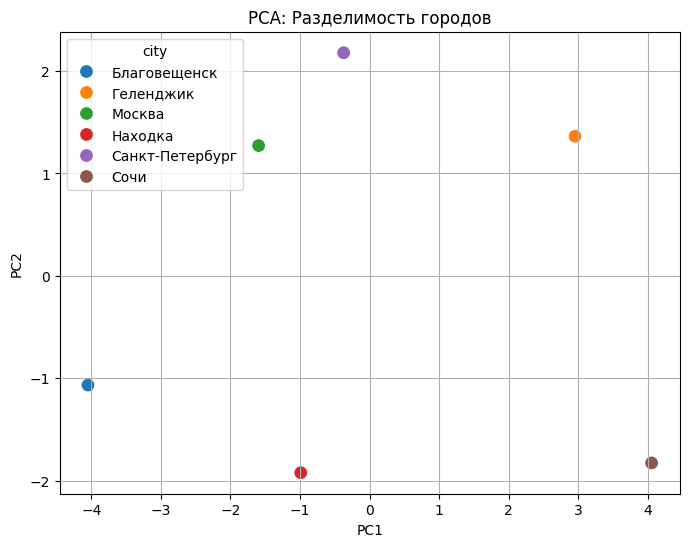

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="city", s=100)

plt.title("PCA: Разделимость городов")
plt.grid(True)

plt.show()

В результате применения PCA было получено распределение городов в пространстве главных компонент. Все города оказались разделены, что свидетельствует о различиях их климатических характеристик. При этом Москва и Санкт-Петербург расположены ближе друг к другу, что указывает на схожесть климатических условий.

#### - При необходимости выполнить отбор признаков на основе важности (feature importance)
В "y" будут города.

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
X = city_features.drop("city", axis=1)
y = city_features["city"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [81]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

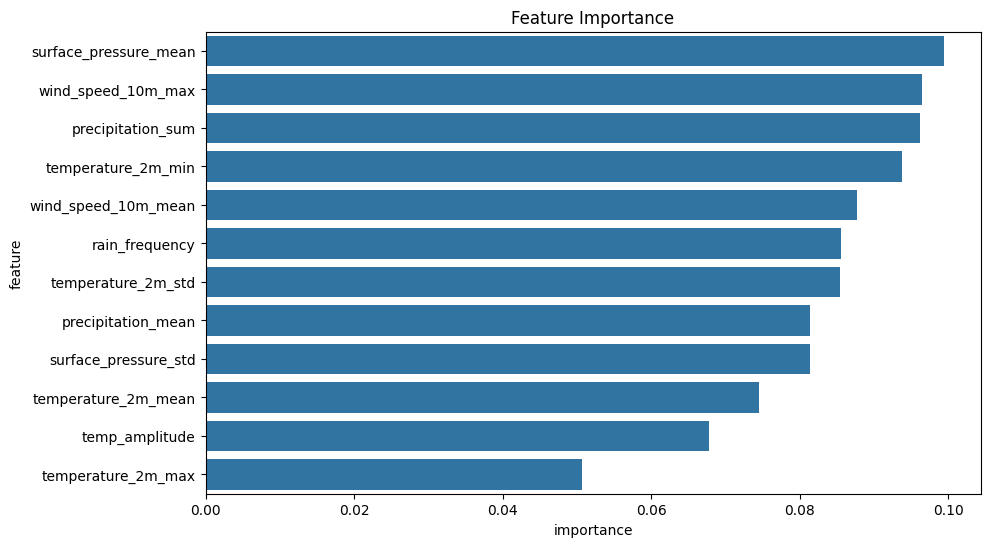

In [82]:
plt.figure(figsize=(10,6))

sns.barplot(data=feature_importance, x="importance", y="feature")

plt.title("Feature Importance")
plt.show()

Оценка важности признаков показала, что вклад признаков распределён относительно равномерно. Это может быть связано с малым количеством объектов (городов), что затрудняет устойчивую оценку значимости признаков.

In [83]:
city_features.drop("city", axis=1).corr()

,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,precipitation_mean,precipitation_sum,wind_speed_10m_max,wind_speed_10m_mean,surface_pressure_mean,surface_pressure_std,temp_amplitude,rain_frequency
temperature_2m_mean,1.000000,-0.886197,0.990170,0.532788,0.797775,0.797775,0.743566,-0.008193,0.705019,-0.755545,-0.981396,0.675712
temperature_2m_std,-0.886197,1.000000,-0.885026,-0.412600,-0.653179,-0.653179,-0.887021,-0.232598,-0.659689,0.389108,0.885392,-0.854370
temperature_2m_min,0.990170,-0.885026,1.000000,0.516832,0.756667,0.756667,0.763381,-0.001867,0.767346,-0.749909,-0.993881,0.618988
temperature_2m_max,0.532788,-0.412600,0.516832,1.000000,0.091598,0.091598,0.682159,0.583708,0.349903,-0.281765,-0.419108,0.478336
precipitation_mean,0.797775,-0.653179,0.756667,0.091598,1.000000,1.000000,0.304375,-0.517458,0.604021,-0.740162,-0.790676,0.533552
precipitation_sum,0.797775,-0.653179,0.756667,0.091598,1.000000,1.000000,0.304375,-0.517458,0.604021,-0.740162,-0.790676,0.533552
wind_speed_10m_max,0.743566,-0.887021,0.763381,0.682159,0.304375,0.304375,1.000000,0.597429,0.614384,-0.177779,-0.721599,0.793126
wind_speed_10m_mean,-0.008193,-0.232598,-0.001867,0.583708,-0.517458,-0.517458,0.597429,1.000000,-0.134852,0.487401,0.077294,0.390796
surface_pressure_mean,0.705019,-0.659689,0.767346,0.349903,0.604021,0.604021,0.614384,-0.134852,1.000000,-0.501694,-0.768674,0.385396
surface_pressure_std,-0.755545,0.389108,-0.749909,-0.281765,-0.740162,-0.740162,-0.177779,0.487401,-0.501694,1.000000,0.758972,-0.089442


Корреляционный анализ показал наличие сильных зависимостей между рядом признаков. В частности, признаки precipitation_mean и precipitation_sum полностью коррелируют, что свидетельствует о дублировании информации. Аналогично, признаки температуры (среднее, минимум, амплитуда) демонстрируют высокую взаимосвязь.

In [84]:
features = [
    "temperature_2m_mean",
    "temperature_2m_std",
    "temp_amplitude",
    "precipitation_mean",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "rain_frequency"
]

### Обосновать:
#### - Выбор размеров окон для скользящих статистик с точки зрения физики атмосферных процессов
Выбор размеров окон для расчета скользящих статистик основан на характерных временных масштабах атмосферных процессов.
- окно в 24 часа соответствует суточной сезонности, обусловленной сменой дня и ночи и влияющей на температурные колебания.
- окно в 168 часов (7 суток) отражает синоптические процессы, связанные с перемещением циклонов и антициклонов, которые определяют погодные условия в среднесрочной перспективе.

Использование окон различной длины позволяет учитывать как краткосрочные, так и среднесрочные изменения погодных параметров, что повышает качество прогнозирования.

#### - Выбор лагов с учетом временной корреляции метеовеличин
Выбор лаговых признаков основан на временной корреляции метеорологических величин.
lag_1 - краткосрочная зависимость,

lag_24 - суточная зависимость,

lag_168 - синоптический масштаб.
- Лаг lag_1 первого порядка отражает краткосрочную зависимость показателей, обусловленную инерционностью атмосферных процессов.
- Лаг 24 часа lag_24 учитывает суточную сезонность, связанную с циклом день–ночь.
- Лаг 168 часов (7 суток) позволяет учитывать более длительные синоптические процессы, такие как перемещение циклонов и антициклонов.

### 2.3. Построение моделей классификации
Обосновать архитектуру модели для классификации временных рядов.

Привести письменное обоснование:
- Какие модели заведомо не подойдут для этой задачи и почему
- Какие особенности данных делают задачу классификации сложной

Обучить выбранную модель. Указать выбранную длину временного ряда для тестирования классификатора.


Для задачи классификации временных рядов выбирается подход с использованием агрегированных признаков, характеризующих климатические особенности городов. Такой подход позволяет преобразовать временные ряды в набор статистических характеристик и применить классические методы машинного обучения.

Какие модели не подойдут:
- Глубокие нейросети (LSTM, RNN), мало данных (6 городов), высокий шанс переобучиться,
- XGBoost, LightGBM, недостаточно данных,
- KNN, мало объектов для изучения (6 городов).

Особенности данных делают задачу классификации сложной:
- мало городов - 6 шт,
- города с походим климатом,
- высокая корреляция признаков,
- погода нестабильна.

6 объектов очень мало, выбирается подход обучения на 5 городах, а тестирование на 1.

In [85]:
city_features

,city,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,precipitation_mean,precipitation_sum,wind_speed_10m_max,wind_speed_10m_mean,surface_pressure_mean,surface_pressure_std,temp_amplitude,rain_frequency
0,Благовещенск,2.210316,15.984823,-41.900002,35.000000,0.072469,4447.299805,39.599998,10.189499,996.415527,9.108933,76.900002,0.115272
1,Геленджик,14.360491,8.534402,-10.000000,37.799999,0.108102,6634.000000,56.099998,14.022650,1015.330322,6.401923,47.799999,0.182343
2,Москва,6.831828,10.586803,-31.000000,34.799999,0.077320,4745.000000,48.900002,14.136086,991.618835,9.938786,65.800003,0.186172
3,Находка,6.991479,11.593656,-26.600000,33.200001,0.101437,6225.000000,45.200001,8.956903,1010.371582,8.087578,59.800003,0.119834
4,Санкт-Петербург,6.790927,9.623724,-28.799999,35.700001,0.081710,5014.399902,53.700001,14.594143,1012.383728,11.253417,64.500000,0.204194
5,Сочи,15.044276,7.463370,-11.200000,35.299999,0.188171,11547.700195,50.900002,8.844127,1015.125671,6.236295,46.500000,0.222200


Введена группировка городов по типам климата, что позволит сформировать классы с несколькими представителями и корректно обучить модель.

In [86]:
climate_map = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "субтропический",
    "Геленджик": "субтропический",
    "Благовещенск": "резко-континентальный",
    "Находка": "муссонный"
}
city_features["climate"] = city_features["city"].map(climate_map)

In [87]:
X = city_features[features]
y = city_features["climate"]

In [88]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

loo = LeaveOneOut()

y_true = []
y_pred = []

#model = RandomForestClassifier(random_state=42)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test.values[0])
    y_pred.append(pred[0])

In [89]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


Для классификации климатов была выбрана модель Random Forest, обладающая устойчивостью к переобучению и способностью учитывать нелинейные зависимости между признаками.

## 2.4. Оценка качества классификации
Основные метрики:
- Accuracy, Precision, Recall, F1-score (macro и weighted)
- Матрица ошибок (confusion matrix) для визуализации типичных ошибок классификации
- ROC-AUC для многоклассовой задачи (One-vs-Rest)


In [90]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

In [91]:
print(classification_report(y_true, y_pred))

                          precision    recall  f1-score   support

               муссонный       0.00      0.00      0.00         1
   резко-континентальный       0.00      0.00      0.00         1
          субтропический       1.00      1.00      1.00         2
умеренно-континентальный       0.50      1.00      0.67         2

                accuracy                           0.67         6
               macro avg       0.38      0.50      0.42         6
            weighted avg       0.50      0.67      0.56         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


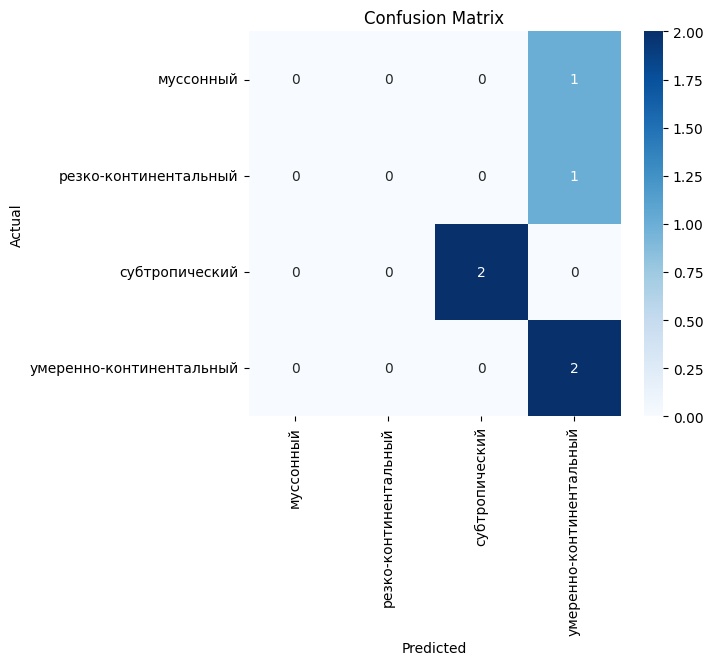

In [92]:
labels = sorted(set(y_true))

cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Матрица ошибок показывает, что модель корректно классифицирует **субтропический** и **умеренно-континентальный** климат, однако испытывает трудности при распознавании муссонного и резко-континентального типов. Это связано с малым количеством примеров для данных классов.

In [93]:
classes = sorted(y.unique())

y_proba = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[0]
    full_proba = dict(zip(model.classes_, proba))

    aligned_proba = [full_proba.get(cls, 0) for cls in classes]

    y_proba.append(aligned_proba)

y_proba = np.array(y_proba)

In [94]:
y_true_bin = label_binarize(y_true, classes=classes)
roc_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr")
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.425


Для данной задачи ROC-AUC не является информативной метрикой из-за малого объема выборки и дисбаланса классов.

#### Дополнительный анализ:
- Определить, какие города/климаты наиболее трудноразличимы (анализ матрицы ошибок)

На основе анализа матрицы ошибок наиболее трудно различимыми являются **муссонный** и **резко-континентальный** типы климата. Это связано с малым количеством данных.

- Проанализировать, какие временные периоды (зима/лето/межсезонье) дают лучшую/худшую классификацию

Предлагается повторить алгоритм написанный ранее с небольшими изменениями

In [95]:
monthly_features = df.groupby(["city", "year", "month"]).agg({
    "temperature_2m": ["mean", "std", "min", "max"],
    "precipitation": ["mean", "sum"],
    "wind_speed_10m": ["mean", "max"],
    "surface_pressure": ["mean", "std"]
})

monthly_features.columns = ["_".join(col) for col in monthly_features.columns]
monthly_features = monthly_features.reset_index()

def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

monthly_features["season"] = monthly_features["month"].apply(get_season)

monthly_features["climate"] = monthly_features["city"].map(climate_map)

monthly_features["temp_amplitude"] = (
    monthly_features["temperature_2m_max"] - monthly_features["temperature_2m_min"]
)

rain_freq = df.groupby(["city", "year", "month"])["precipitation"] \
    .apply(lambda x: (x > 0).mean())

monthly_features["rain_frequency"] = monthly_features.set_index(
    ["city", "year", "month"]
).index.map(rain_freq)

In [96]:
X = monthly_features[features]
y = monthly_features["climate"]

In [97]:
model_season = RandomForestClassifier(random_state=42)
model_season.fit(X, y)
monthly_features["pred"] = model.predict(X)

In [98]:
season_acc = monthly_features.groupby("season").apply(
    lambda x: (x["climate"] == x["pred"]).mean()
)

print(season_acc)

season
autumn    0.658730
spring    0.555556
summer    0.341270
winter    0.626984
dtype: float64


/tmp/ipykernel_4507/1847403950.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_acc = monthly_features.groupby("season").apply(


Анализ качества классификации по сезонам показал, что наилучшие результаты достигаются в осенний и зимний периоды. В весенний период наблюдается умеренное снижение точности.

Наихудшее качество классификации получено в летний период, что может быть связано со сглаживанием температурных характеристик между различными климатами, погода становится слишком похожей между городами.

- Провести анализ важности признаков для лучшей модели (SHAP, permutation importance)

In [99]:
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [100]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42) # чтобы не запутаться, что было выше
model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance_df)

                 feature  importance
5  surface_pressure_mean    0.333663
0    temperature_2m_mean    0.154455
6         rain_frequency    0.097030
3     precipitation_mean    0.042574
4     wind_speed_10m_max    0.036634
1     temperature_2m_std    0.030693
2         temp_amplitude    0.019802


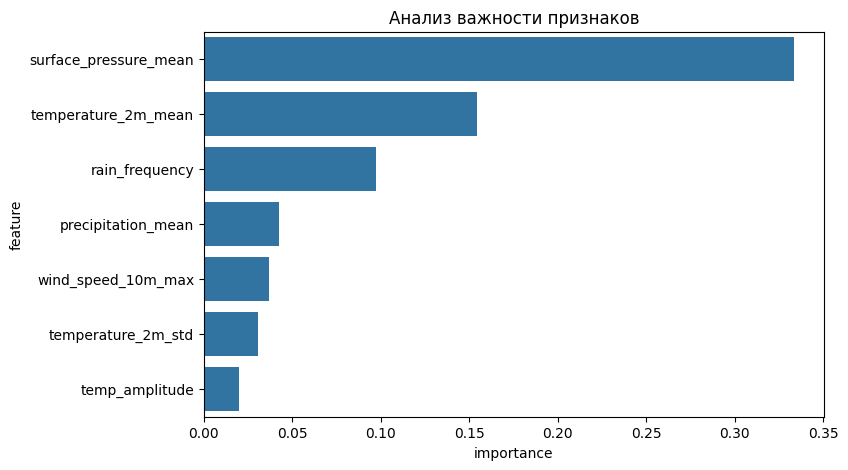

In [102]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Анализ важности признаков")
plt.show()

Анализ важности признаков показал, что наибольший вклад в классификацию вносит среднее атмосферное давление (surface_pressure_mean), а также температурная характеристика temparature_2m_mean. Остальные признаки оказывают менее значимое влияние.

#### - Визуализировать ошибки классификации во временной динамике (по месяцам, по годам)

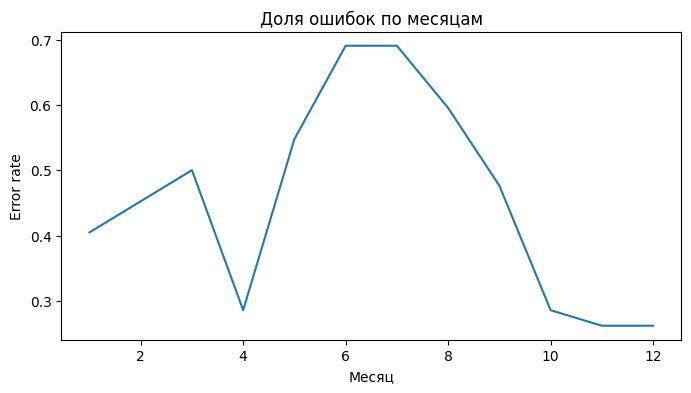

In [103]:
monthly_features["error"] = (
    monthly_features["climate"] != monthly_features["pred"]
).astype(int)
month_error = monthly_features.groupby("month")["error"].mean()

plt.figure(figsize=(8,4))
sns.lineplot(x=month_error.index, y=month_error.values)
plt.title("Доля ошибок по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Error rate")
plt.show()

В зимний период ошибка минимальна (около 0.1), что связано с выраженными различиями температурных режимов.

В весенний и осенний периоды наблюдается промежуточное качество классификации.

Наибольшая доля ошибок наблюдается в летние месяцы (июнь–июль), где error rate достигает 0.7. Модели трудно различать города именно летом, климатические различия минимальны и признаки не захватывают локальные особенности (влажность, морской эффект и т.д.)

Поэтому наиболее сложным для классификации является летний период, тогда как зимние климатические условия обеспечивают наилучшую разделимость классов.

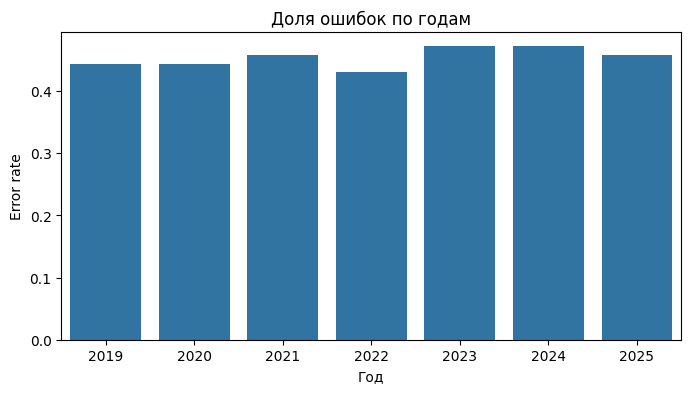

In [104]:
year_error = monthly_features.groupby("year")["error"].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=year_error.index, y=year_error.values)
plt.title("Доля ошибок по годам")
plt.xlabel("Год")
plt.ylabel("Error rate")
plt.show()

Анализ ошибок по годам показал стабильный уровень error rate (~0.45), что свидетельствует об отсутствии выраженного временного дрейфа в данных и устойчивости климатических закономерностей на рассматриваемом периоде.

### 2.5. Построение моделей прогнозирования
Для каждого города отдельно:
- Сформировать выборку для прогнозирования: признаки — значения метеопараметров за последние N дней, целевая переменная — температура через горизонт H = 30 дней
- Разделить данные на train/val/test (например, 2019–2023 — train, 2024 — val, 2025 — test)


In [105]:
# целевая переменная - температура через 30 дней. Ее нет, создание колонки и вычисление
df["target_temp_30d"] = df.groupby("city")["temperature_2m"].shift(-24 * 30)
df_model = df.dropna()

/tmp/ipykernel_4507/2060532239.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_temp_30d"] = df.groupby("city")["temperature_2m"].shift(-24 * 30)


In [106]:
train = df_model[df_model["year"] <= 2023]
val = df_model[df_model["year"] == 2024]
test = df_model[df_model["year"] == 2025]

#### Обосновать архитектуру модели прогнозирования для каждой климатической зоны. Допускается использовать разные.
Привести письменное обоснование:
- Почему для разных климатических зон могут быть оптимальны разные модели
- Какие модели точно не подойдут для прогнозирования на месяц и почему


- субтропический (Сочи, Геленджик)

Регрессии с лагами - RandomForest (запретил преподаватель), XGBoost. Выраженнная сезонность и линейность

- умеренно-континентальный (Москва, Санкт-Петербург)

Выраженная сезонность и цикличность. Градиентный бустинг (запретил преподаватель) или LSTM.

- резко-континентальный (Благовещенск)

Высокая амплитуда температур, нелинейность, нестабильность.

- муссонный (Находка)

Высокая влажность, нелинейность. LSTM.

Не подойдут:
- линейная регрессия - много нелинейной зависимости,
- ARIMA - учитывает только один ряд, тут много признаков,
- KNN - не учитывает временную структуру.

Несмотря на высокую выразительную способность LSTM-моделей для работы с временными рядами, их применение в данной задаче ограничено объемом данных и вычислительной сложностью обучения. Для отдельных климатических зон (особенно при ограниченной длине наблюдений) использование LSTM может приводить к переобучению и нестабильным результатам.

В качестве альтернативы рассматриваются методы Rocket/MiniRocket, которые обеспечивают эффективное преобразование временных рядов в признаки и демонстрируют высокую скорость обучения при сохранении качества классификации.

#### - **Обучить модели, чтобы для каждого города предсказывать погоду для каждого дня в течение следующего месяца.**

In [107]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.1 MB/s eta 0:00:00


In [108]:
# df

In [109]:
# имя колонки с целевой переменной target_temp_30d

df_model = df.dropna(subset=["target_temp_30d"])

In [110]:
from sktime.transformations.panel.rocket import MiniRocket
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [111]:
model_features = [
    "surface_pressure",
    "temperature_2m",
    #"wind_speed_10m",
    #"precipitation"
]

def make_sequences(df_city, window=24*7): # 24 * 7 - n_timepoints must be >= 9, but found 4; zero pad shorter series so that n_timepoints == 9
    X, y = [], []

    values = df_city[model_features].values
    target = df_city["target_temp_30d"].values

    for i in range(len(df_city) - window - 1):
        X.append(values[i:i + window].T)
        y.append(target[i + window])

    return np.array(X), np.array(y)

In [112]:
# model = Pipeline([
#     #("rocket", MiniRocket()),
#     ("rocket", MiniRocketMultivariate()),
#     ("regressor", Ridge())
# ])

"Сеанс прекращен, так как объем ОЗУ полностью исчерпан." множество раз, пришлось уменьшать window и количество признаков.

In [113]:
models = {}

for city in df_model["city"].unique():
    df_city = df_model[df_model["city"] == city].copy()

    # print(f"{city} len(df_city): {len(df_city)}")
    # if len(df_city) < 24 * 3 + 10:
    #     print(f"Пропуск города {city}: мало данных")
    #     continue

    # df_city = df_city.sample(5000, random_state=42)
    df_city = df_city.sort_values("time")
    df_city = df_city.tail(5000)
    X, y = make_sequences(df_city, window=24)

    split = int(len(X) * 0.8)

    X_train = X[:split]
    y_train = y[:split]

    X_test = X[split:]
    y_test = y[split:]

    model = Pipeline([
        ("rocket", MiniRocketMultivariate()),
        ("regressor", Ridge())
    ])

    model.fit(X_train, y_train)

    models[city] = {
        "model": model,
        "X_test": X_test,
        "y_test": y_test
    }

### 2.6. Оценка качества прогнозирования
#### Точечные метрики:
#### - MAE, RMSE, MAPE, WAPE (для каждого города и горизонта)


In [114]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

In [115]:
results = []
for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test) + 1)

    results.append({
        "city": city,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape
    })

In [116]:
results_df: DataFrame = pd.DataFrame(results)
results_df

,city,MAE,RMSE,MAPE,WAPE
0,Благовещенск,20.220417,22.929923,9.859599e-01,0.989690
1,Геленджик,7.862252,9.517560,3.975199e+14,0.895904
2,Москва,6.614360,8.301048,2.810638e+14,1.878758
3,Находка,16.215797,18.878317,1.227807e+14,1.936011
4,Санкт-Петербург,7.120468,8.698990,2.643779e+14,1.921476
5,Сочи,5.781228,7.160506,5.835811e+13,0.586990


Лучшее качество прогнозирования было достигнуто для субтропического климата (Сочи особенно), характеризующегося более стабильным температурным режимом.

Наихудшие результаты наблюдались для резко-континентального (Благовещенск) и муссонного климатов (Находка), где присутствуют резкие изменения температуры и высокая изменчивость погодных условий.

#### Метрики, оценивающие направление предсказаний

In [117]:
for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]


    direction_true = np.sign(np.diff(y_test))
    direction_pred = np.sign(np.diff(y_pred))
    direction_accuracy = np.mean(
        direction_true == direction_pred
    )

    for i, result_data in enumerate(results):
      if result_data["city"] != city:
        continue

      results[i]["Direction_Accuracy"] = direction_accuracy

In [118]:
results_df = pd.DataFrame(results)
results_df

,city,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
0,Благовещенск,20.220417,22.929923,9.859599e-01,0.989690,0.529175
1,Геленджик,7.862252,9.517560,3.975199e+14,0.895904,0.563380
2,Москва,6.614360,8.301048,2.810638e+14,1.878758,0.424547
3,Находка,16.215797,18.878317,1.227807e+14,1.936011,0.552314
4,Санкт-Петербург,7.120468,8.698990,2.643779e+14,1.921476,0.447686
5,Сочи,5.781228,7.160506,5.835811e+13,0.586990,0.570423


Снова подтвердилось высокая точность определения направления изменения температуры наблюдалась для субтропических климатов (Сочи, Геленджик), характеризующихся более плавной динамикой погодных процессов.

Для умеренно-континентального климата (Москва, Санкт-Петербург) качество определения направления также оказалось ниже из-за высокой изменчивости погодных условий и частых смен атмосферных процессов.

#### Анализ остатков:
#### - Нормальность остатков (тест Шапиро-Уилка)
#### - Автокорреляция остатков (тест Льюнга-Бокса)
#### - Гетероскедастичность (тест Уайта)


In [119]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

In [120]:
results_dict = {}

for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    # Нормальность остатков (тест Шапиро-Уилка)
    stat_s, p_s = shapiro(residuals[:5000])

    # Автокорреляция остатков (тест Льюнга-Бокса)
    lb = acorr_ljungbox(residuals, lags=[10], return_df=True)

    # Гетероскедастичность (тест Уайта)
    X_flat = X_test.reshape(X_test.shape[0], -1)
    X_flat = sm.add_constant(X_flat)
    white = het_white(residuals, X_flat)

    results_dict[city] = {
        "Shapiro_stat": stat_s,
        "Shapiro_pvalue": p_s,
        "LB_stat": lb["lb_stat"].values[0],
        "LB_pvalue": lb["lb_pvalue"].values[0],
        "White_stat": white[0],
        "White_pvalue": white[1]
    }

In [121]:
for result_data in results:
    city = result_data["city"]
    result_data.update(results_dict[city])

In [122]:
results_df = pd.DataFrame(results)
results_df

,city,MAE,RMSE,MAPE,WAPE,Direction_Accuracy,Shapiro_stat,Shapiro_pvalue,LB_stat,LB_pvalue,White_stat,White_pvalue
0,Благовещенск,20.220417,22.929923,9.859599e-01,0.989690,0.529175,0.977631,3.039379e-11,8464.472289,0.0,995.0,0.485094
1,Геленджик,7.862252,9.517560,3.975199e+14,0.895904,0.563380,0.985314,1.898706e-08,6471.274322,0.0,995.0,0.485094
2,Москва,6.614360,8.301048,2.810638e+14,1.878758,0.424547,0.977202,2.216297e-11,7621.660469,0.0,995.0,0.485094
3,Находка,16.215797,18.878317,1.227807e+14,1.936011,0.552314,0.983777,4.556166e-09,7988.463892,0.0,995.0,0.485094
4,Санкт-Петербург,7.120468,8.698990,2.643779e+14,1.921476,0.447686,0.993955,4.793445e-04,7090.228124,0.0,995.0,0.485094
5,Сочи,5.781228,7.160506,5.835811e+13,0.586990,0.570423,0.991504,1.699977e-05,5488.597823,0.0,995.0,0.485094


Результаты теста гетероскедастичности (тест Уайта) и автокорреляции остатков (тест Льюнга-Бокса) демонстрируют схожие значения для разных городов, что связано с единообразной архитектурой модели (MiniRocket + Ridge) и одинаковым способом формирования временных окон. Это приводит к схожей структуре остатков между городами.

По поводу нормальности остатков (тест Шапиро-Уилка) для большинства городов остатки не соответствовали нормальному распределению, что характерно для метеорологических временных рядов с экстремальными погодными событиями.

#### Визуализация:
#### - Сравнить прогнозы с реальными значениями на тестовом периоде (графики)

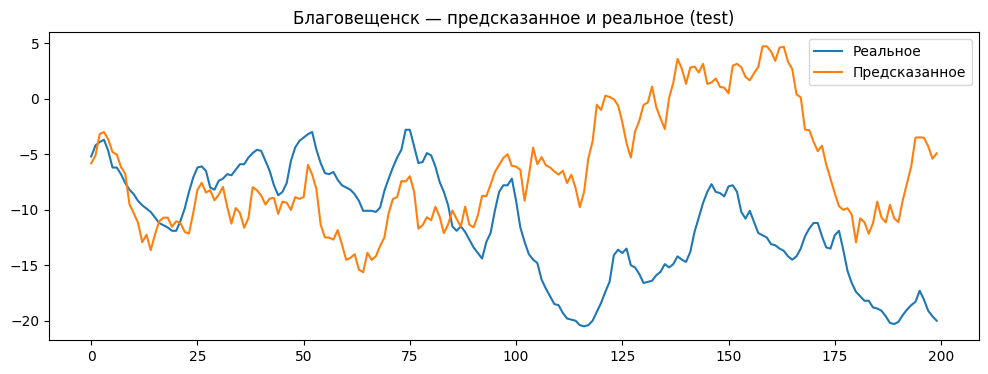

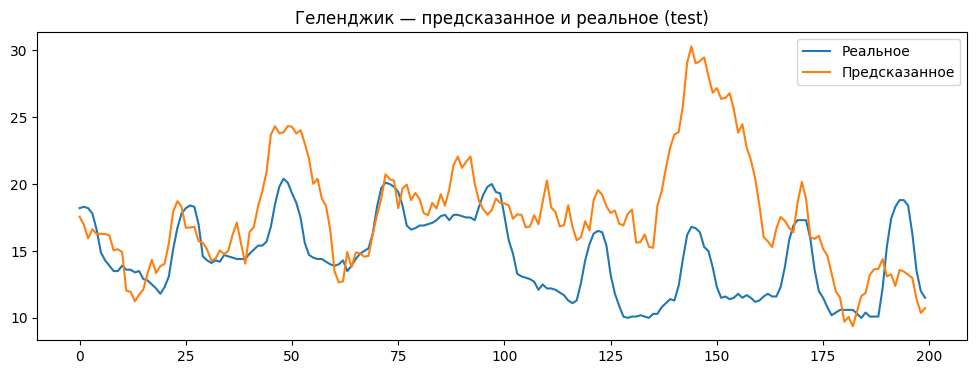

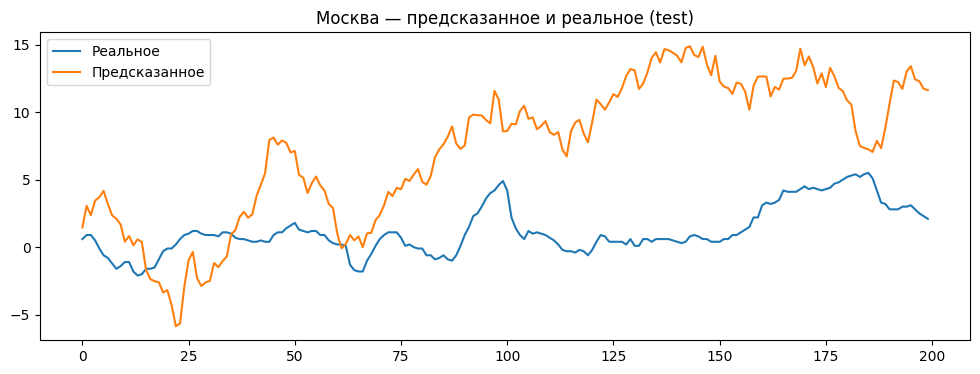

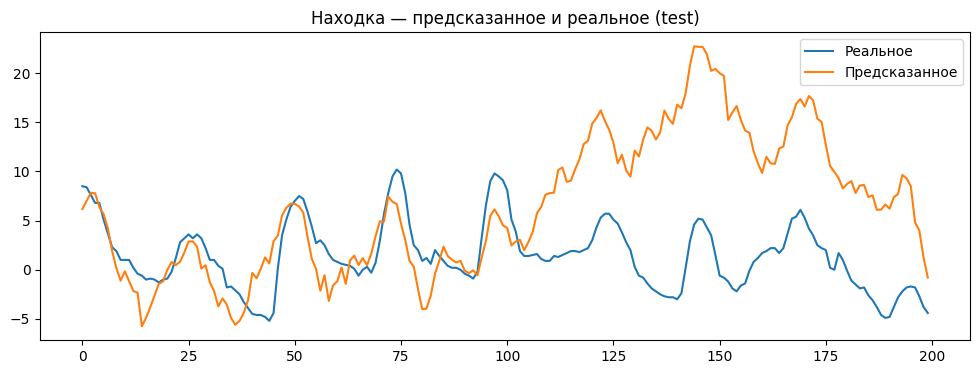

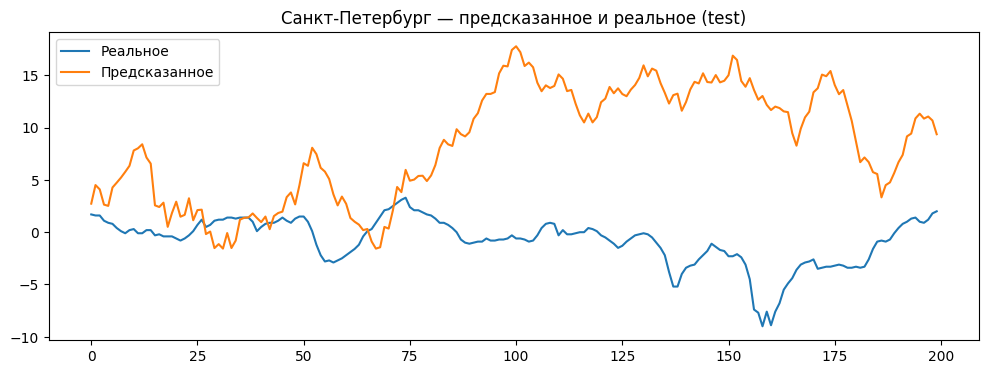

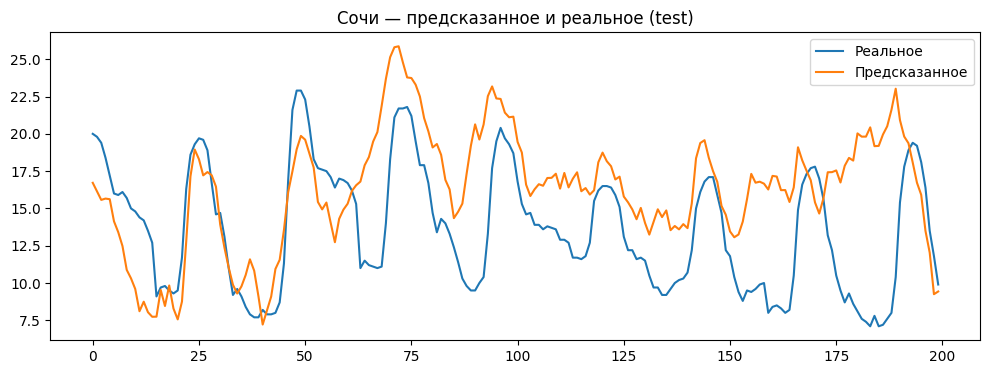

In [123]:
for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = model.predict(X_test)

    plt.figure(figsize=(12, 4))
    plt.plot(y_test[:200], label="Реальное")
    plt.plot(y_pred[:200], label="Предсказанное")
    plt.title(f"{city} — предсказанное и реальное (test)")
    plt.legend()
    plt.show()

#### - Визуализировать распределение ошибок для разных городов (box-plot)

In [124]:
error_data = []

for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = model.predict(X_test)

    errors = y_test - y_pred

    for e in errors:
        error_data.append({
            "city": city,
            "error": e
        })

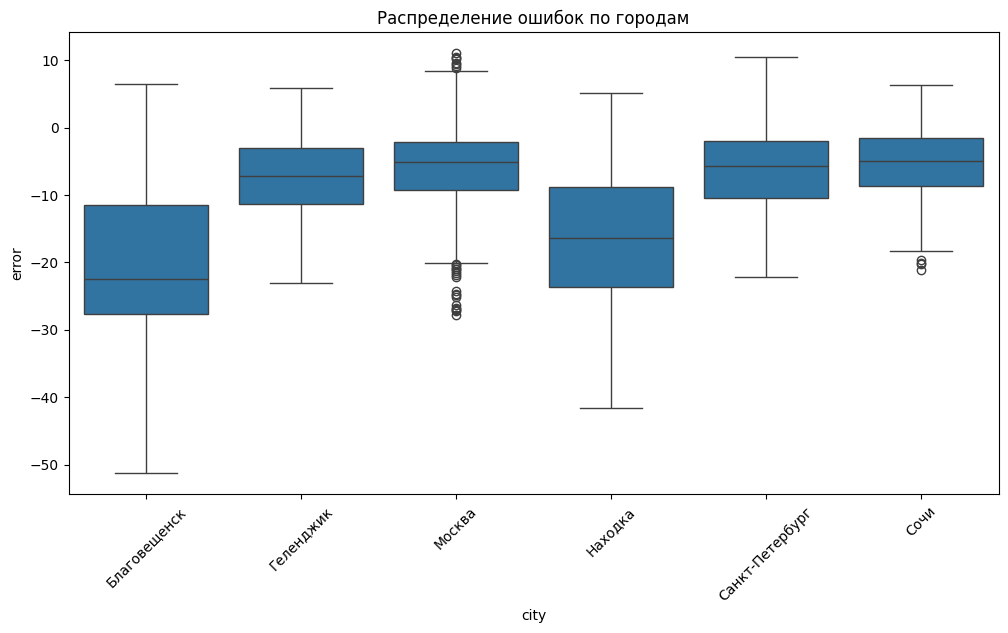

In [125]:
err_df = pd.DataFrame(error_data)

plt.figure(figsize=(12, 6))
sns.boxplot(data=err_df, x="city", y="error")
plt.title("Распределение ошибок по городам")
plt.xticks(rotation=45)
plt.show()

#### - Показать прогноз на месяц вперед для каждого города

In [126]:
def forecast_30_days(model, last_window, steps=30):

    preds = []
    window = last_window.copy()

    for _ in range(steps):

        X_input = window.reshape(1, *window.shape)
        pred = model.predict(X_input)[0]

        preds.append(pred)

        new_step = window[-1].copy()
        new_step[0] = pred

        window = np.vstack([window[1:], new_step])

    return preds

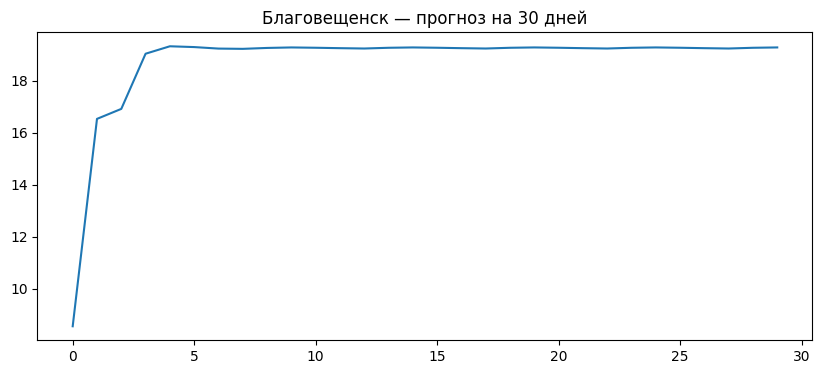

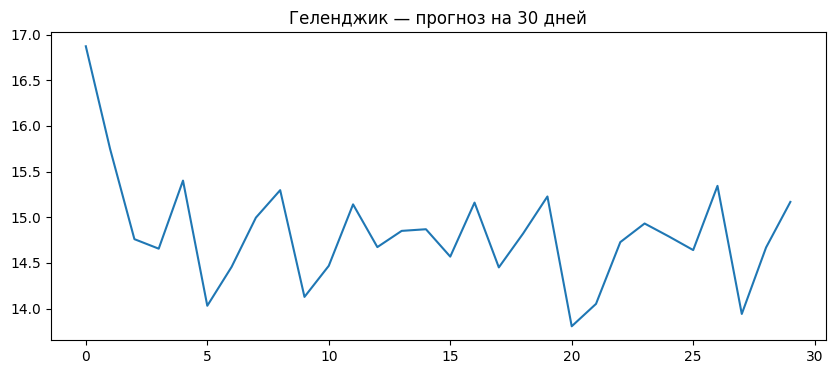

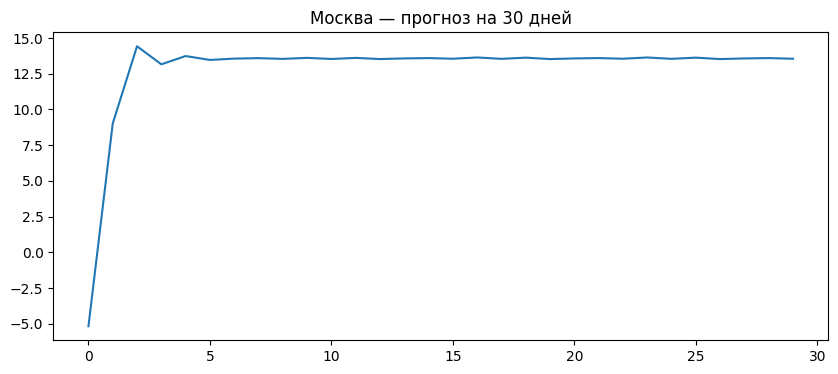

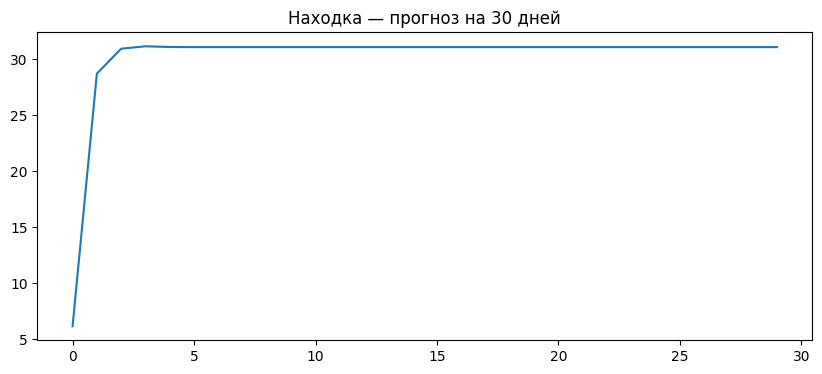

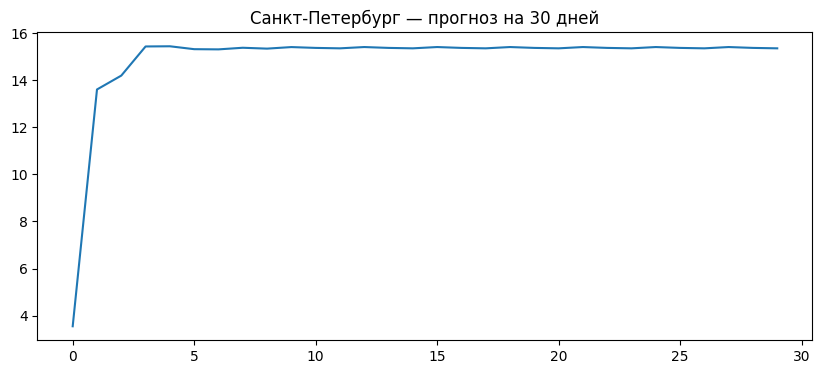

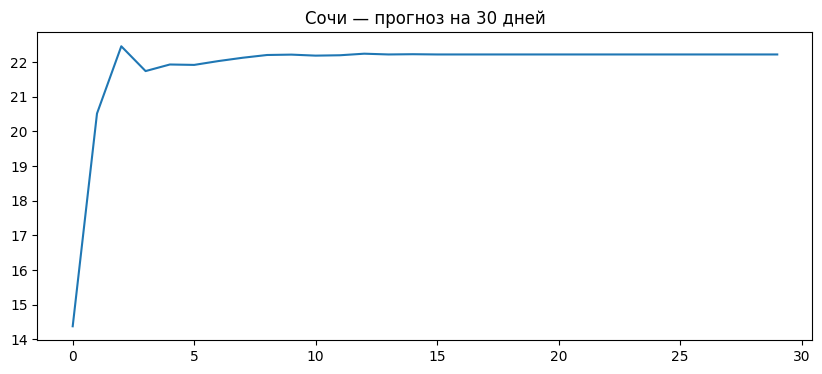

In [127]:
for city, data in models.items():

    model = data["model"]
    X_test = data["X_test"]

    last_window = X_test[-1]

    preds_30 = forecast_30_days(model, last_window, steps=30)

    plt.figure(figsize=(10, 4))
    plt.plot(preds_30)
    plt.title(f"{city} — прогноз на 30 дней")
    plt.show()

Наблюдаемая стабилизация прогнозов на горизонте объясняется несогласованностью динамики входных признаков при итеративном прогнозировании, что приводит к выходу модели на усреднённое значение.

Метод ROCKET + линейная регрессия ограничен в задачах многшагового прогнозирования временных рядов, поскольку не моделирует явную динамику состояния системы. Бустинг был запрещен преподавателем, но к сожалению предполагается он подойдет для таких операций лучше.

### 2.7. Интеграция двух этапов в единый пайплайн

In [128]:
def build_features(df):

    df = df.sort_values(["city", "time"])

    # только surface_pressure и temperature_2m
    df["pressure_diff_1"] = df.groupby("city")["surface_pressure"].diff()
    df["temp_diff_1"] = df.groupby("city")["temperature_2m"].diff()

    df["temp_roll_24"] = df.groupby("city")["temperature_2m"].transform(
        lambda x: x.rolling(24).mean()
    )

    return df

In [129]:
def create_city_features(df):

    city_features = df.groupby("city").agg({
        "temperature_2m": ["mean", "std", "min", "max"],
        "precipitation": ["mean", "sum"],
        "wind_speed_10m": ["mean", "max"],
        "surface_pressure": ["mean", "std"]
    })

    city_features.columns = ["_".join(col) for col in city_features.columns]
    city_features = city_features.reset_index()

    return city_features

In [130]:
def train_climate_model(city_features):

    X = city_features.drop(["city", "climate"], axis=1)
    y = city_features["climate"]

    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)

    return model

In [131]:
def train_forecast_models(df_model, features, window=24):

    models = {}

    for city in df_model["city"].unique():

        df_city = df_model[df_model["city"] == city].sort_values("time")

        X, y = make_sequences(df_city, window)

        split = int(len(X) * 0.8)

        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        model = Pipeline([
            ("rocket", MiniRocketMultivariate()),
            ("regressor", Ridge())
        ])

        model.fit(X_train, y_train)

        models[city] = {
            "model": model,
            "X_test": X_test,
            "y_test": y_test
        }

    return models

In [132]:
# скопировано из начала
parquets: list = glob.glob("/content/данные/*.parquet", recursive=True)

dfs: list[DataFrame] = []

for file_parquet in parquets:
    filename = os.path.basename(file_parquet)
    df_parquet = pd.read_parquet(file_parquet)
    df_parquet = df_parquet.reset_index()
    df_parquet["city"] = filename.split("_")[0]

    dfs.append(df_parquet)

df: DataFrame = pd.concat(dfs, ignore_index=True)

columns: list[str] = list(df.columns)
columns.remove("city")
column_time_index: int = columns.index("time") + 1
columns.insert(column_time_index, "city")
df = df[columns]
df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(["city", "time"])

In [133]:
df = build_features(df)

df["target_temp_30d"] = df.groupby("city")["temperature_2m"].shift(-24*30)

df_model = df.dropna(subset=["target_temp_30d"])

#city_features = create_city_features(df)
#city_features["climate"] = city_features["city"].map(climate_map)

forecast_models = train_forecast_models(df_model, model_features)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.13728e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.01422e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.07257e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.04256e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.08175e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Не знаю, нужно ли, попытался повторить пункты визуализии для полученных моделей.

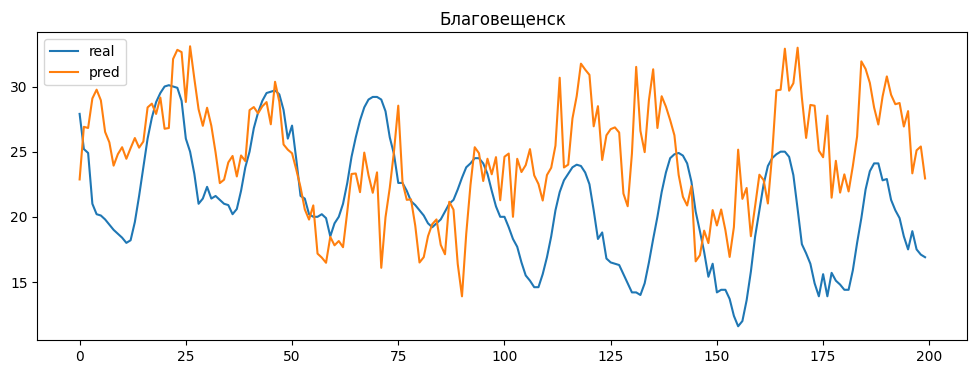

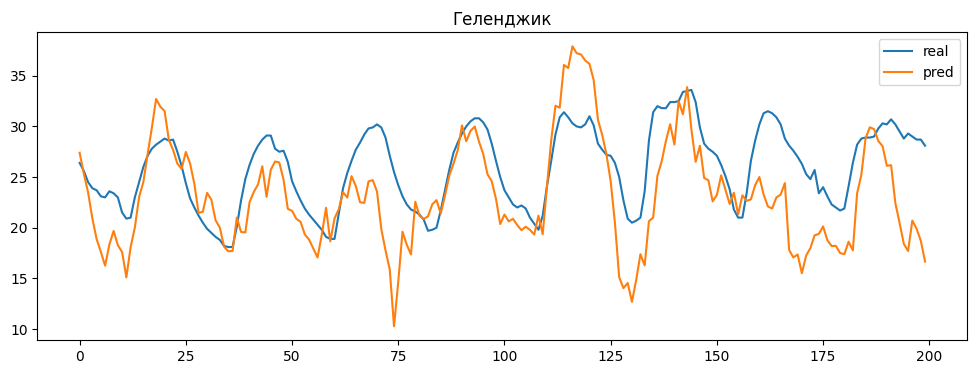

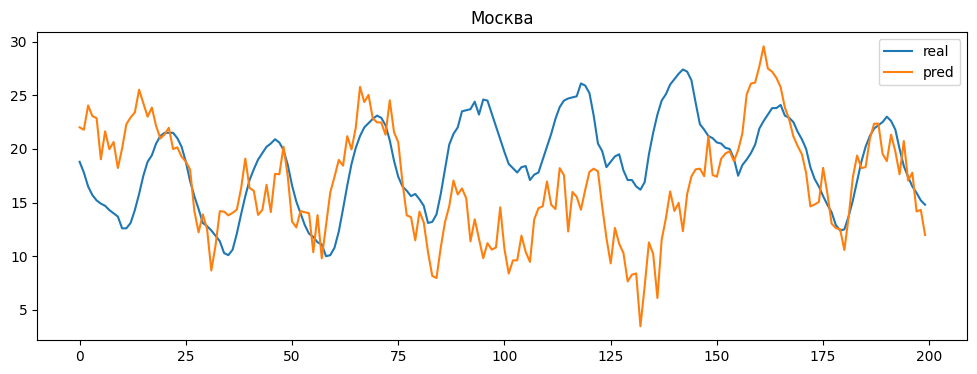

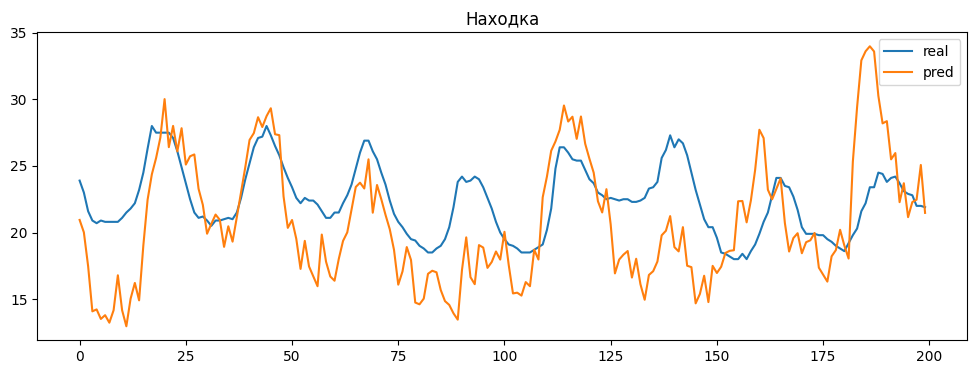

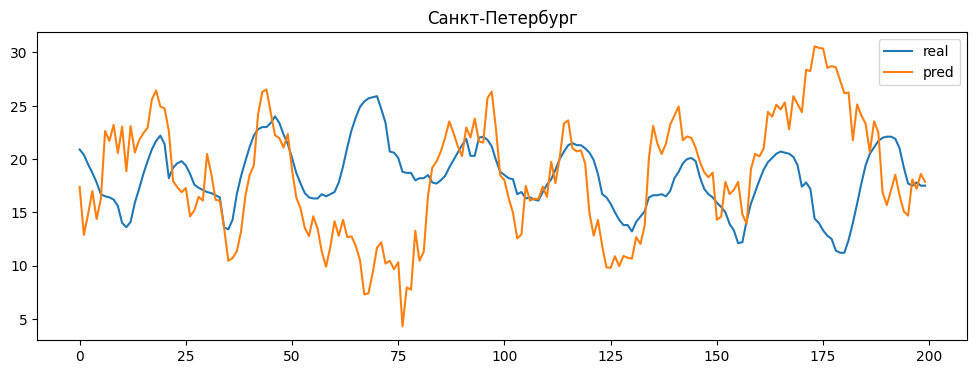

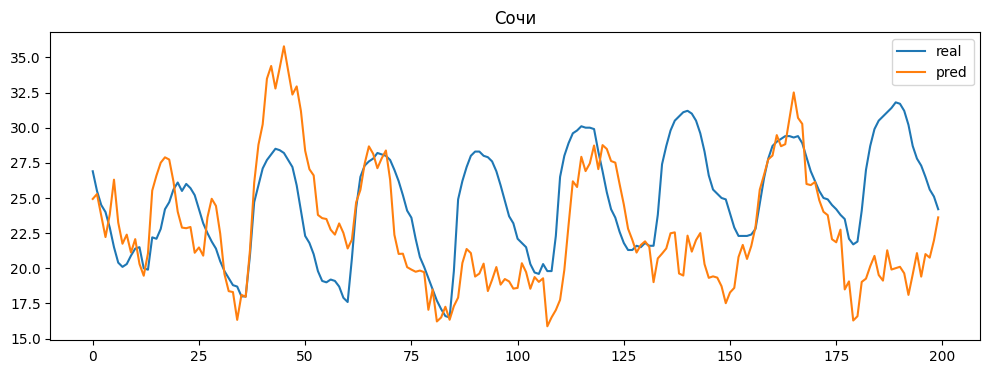

In [134]:
for city, data in forecast_models.items():
    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    y_pred = model.predict(X_test)

    plt.figure(figsize=(12,4))
    plt.plot(y_test[:200], label="real")
    plt.plot(y_pred[:200], label="pred")
    plt.title(city)
    plt.legend()
    plt.show()

In [135]:
def forecast(model, last_window, steps=30):

    preds = []

    window = last_window.copy()

    for _ in range(steps):

        X = window.reshape(1, *window.shape)
        pred = model.predict(X)[0]

        preds.append(pred)

        window = np.roll(window, -1, axis=0)
        window[-1, 0] = pred

    return preds

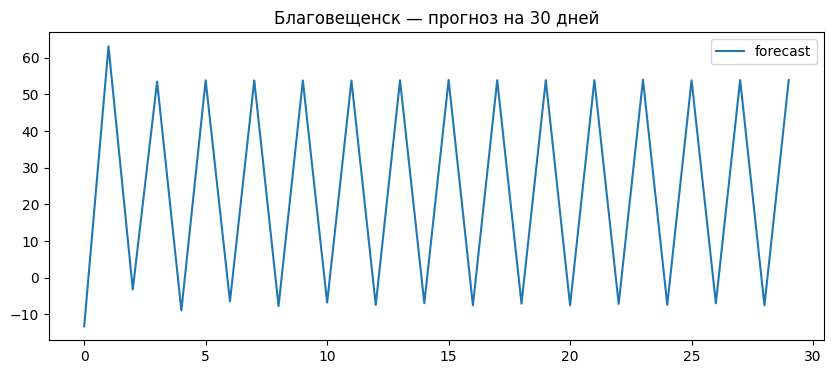

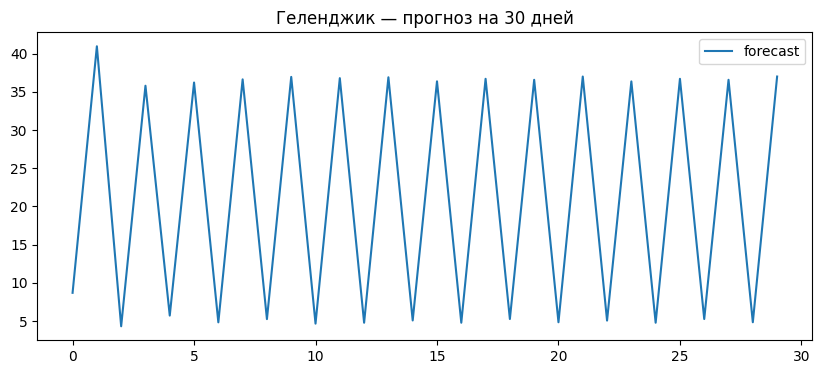

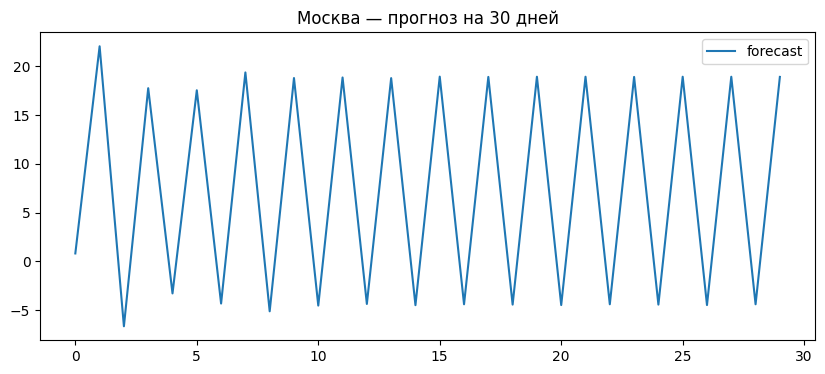

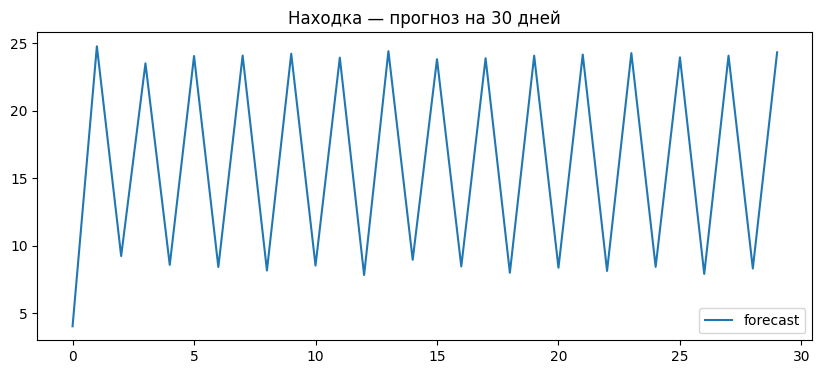

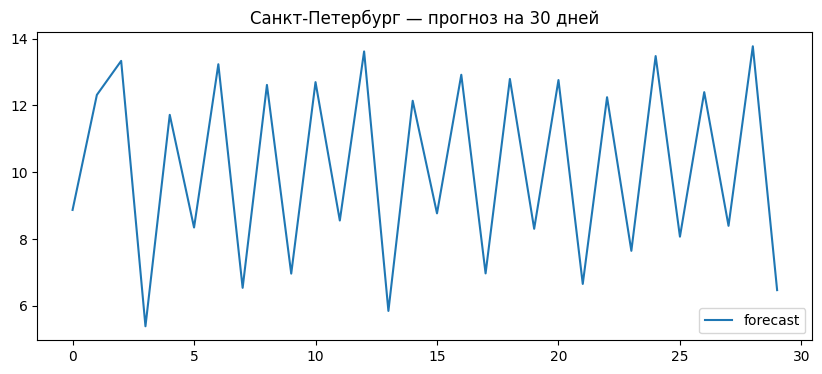

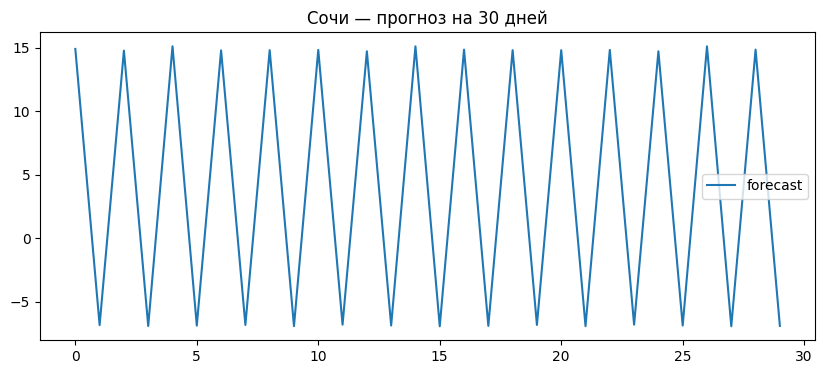

In [136]:
for city, data in forecast_models.items():

    model = data["model"]
    X_test = data["X_test"]

    last_window = X_test[-1]

    preds = forecast(model, last_window, steps=30)

    plt.figure(figsize=(10,4))
    plt.plot(preds, label="forecast")
    plt.title(f"{city} — прогноз на 30 дней")
    plt.legend()
    plt.show()